---
# ASK

## Does 3-point shooting affect win rate?

Across NCAA college basketball and the NBA (regular season and playoffs), we investigate whether 3-point shooting — both accuracy and volume — has a meaningful effect on team win rate.

---

## Datasets

### 1. NCAA — March Madness Data
**Source:** [Kaggle — nishaanamin/march-madness-data](https://www.kaggle.com/datasets/nishaanamin/march-madness-data)

Two CSV files covering all Division I teams from 2008 to 2026:
- **KenPom/Barttorvik** — efficiency ratings, 3PT shooting percentages, tournament outcomes, pace, and talent rankings
- **Shooting Splits** — per-team shot selection breakdowns (3s, close 2s, mid-range, dunks) available from 2010 onward

The two files are joined on `YEAR` + `TEAM ID`.

---

### 2. NBA Regular Season
**Source:** [Kaggle — mharvnek/nba-team-stats-00-to-18](https://www.kaggle.com/datasets/mharvnek/nba-team-stats-00-to-18)

Team-level season averages from 2000 to 2018 covering win percentage, 3PT percentage, 3PT shooting volume, and other shooting metrics. Allows analysis of how the 3PT–win relationship has shifted over two decades of league-wide style change.

---

### 3. NBA Playoffs
**Source:** [Kaggle — mharvnek/nba-team-stats-00-to-18](https://www.kaggle.com/datasets/mharvnek/nba-team-stats-00-to-18)

Per-team playoff statistics (2000–2021) including 3PT attempts, makes, percentage, and win percentage. Playoff basketball provides a higher-stakes context where shooting efficiency is expected to matter more.

---
# NCAA

---
# PREPARE

## 1. Data Collection

Two CSV files from Kaggle: KenPom/Barttorvik (efficiency ratings, 3PT stats, tournament outcomes) and Shooting Splits (shot type breakdowns). Linked by `YEAR` + `TEAM ID`.

In [16]:
import pandas as pd
import numpy as np
import os

DATA_DIR = os.path.join(os.getcwd(), 'data')

kp = pd.read_csv(os.path.join(DATA_DIR, 'KenPom Barttorvik.csv'))
ss = pd.read_csv(os.path.join(DATA_DIR, 'Shooting Splits.csv'))

print('Data directory:', DATA_DIR)
print()
print(f'KenPom Barttorvik : {kp.shape[0]:,} rows  |  {kp.shape[1]} columns')
print(f'Shooting Splits   : {ss.shape[0]:,} rows  |  {ss.shape[1]} columns')
print()
print(f'KenPom years  : {sorted(kp["YEAR"].unique())}')
print(f'Splits years  : {sorted(ss["YEAR"].unique())}')

Data directory: c:\Users\travi\OneDrive\Desktop\workspace\coursework\sc3021\ncaa\data

KenPom Barttorvik : 1,215 rows  |  103 columns
Shooting Splits   : 1,085 rows  |  37 columns

KenPom years  : [np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]
Splits years  : [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]


### KenPom Barttorvik — Column Dictionary

| Column | Type | Description |
|---|---|---|
| `YEAR` | int | Season year |
| `TEAM ID` | int | Unique team identifier |
| `TEAM` | str | Team name |
| `CONF` | str | Conference (e.g. ACC, SEC, B12) |
| `SEED` | float | NCAA tournament seed (1–16); NaN if team did not qualify |
| `ROUND` | int | Tournament round reached — encoded as bracket size: 0=No Tourney, 68=First Four, 64=R64, 32=R32, 16=S16, 8=E8, 4=F4, 2=Final, 1=Champion |
| `W` | int | Regular season + tournament wins |
| `L` | int | Regular season + tournament losses |
| `WIN%` | float | Win percentage (W / Games) |
| `GAMES` | int | Total games played |
| `KADJ EM` | float | **KenPom Adjusted Efficiency Margin** — net points per 100 possessions vs average D1 opponent (higher = better) |
| `KADJ O` | float | **KenPom Adjusted Offensive Efficiency** — points scored per 100 possessions, adjusted for opponent quality |
| `KADJ D` | float | **KenPom Adjusted Defensive Efficiency** — points allowed per 100 possessions, adjusted for opponent quality (lower = better) |
| `BARTHAG` | float | **Barttorvik win probability** vs an average D1 team (0–1 scale) |
| `BADJ EM` | float | **Barttorvik Adjusted Efficiency Margin** — similar to KADJ EM using Barttorvik's model |
| `3PT%` | float | Offensive 3-point field goal percentage |
| `3PTR` | float | **3PT attempt rate** — percentage of offensive FG attempts that are 3-pointers |
| `3PT%D` | float | Defensive 3PT FG% — percentage of opponent 3-pointers that go in |
| `3PTRD` | float | **Opponent 3PT attempt rate** — percentage of opponent shots that are 3-pointers |
| `EFG%` | float | **Effective FG% (offence)** — accounts for 3PT being worth more: (FGM + 0.5×3PM) / FGA |
| `EFG%D` | float | **Effective FG% (defence)** — opponent EFG% allowed |
| `2PT%` | float | Offensive 2-point field goal percentage |
| `2PT%D` | float | Defensive 2-point field goal percentage allowed |
| `2PTR` | float | 2PT attempt rate — share of shots that are 2-pointers |
| `2PTRD` | float | Opponent 2PT attempt rate |
| `KADJ T` | float | **KenPom Adjusted Tempo** — possessions per 40 minutes, adjusted for opponent pace |
| `K TEMPO` | float | Raw tempo — actual possessions per game |
| `PPPO` | float | **Points per possession (offence)** — raw scoring efficiency |
| `FT%` | float | Free throw percentage |
| `FTR` | float | **Free throw rate** — free throw attempts per field goal attempt |
| `TALENT` | float | Composite talent rating based on recruiting rankings |
| `EXP` | float | Team experience rating (weighted average years in program) |
| `WAB` | float | **Wins Above Bubble** — wins vs what a bubble-level team would earn on the same schedule |
| `ELITE SOS` | float | **Strength of schedule** — quality of opponents faced |

### Shooting Splits — Column Dictionary

| Column | Type | Description |
|---|---|---|
| `YEAR` | int | Season year |
| `TEAM ID` | int | Unique team identifier (joins to KenPom on YEAR + TEAM ID) |
| `THREES FG%` | float | Offensive 3-point FG% |
| `THREES SHARE` | float | Share of total offensive shot attempts that are 3-pointers (%) |
| `THREES FG%D` | float | Defensive 3PT FG% allowed |
| `THREES D SHARE` | float | Share of opponent shots that are 3-pointers (%) |
| `CLOSE TWOS FG%` | float | FG% on close 2-pointers (layups, short paint shots) — offence |
| `CLOSE TWOS SHARE` | float | Share of shots that are close 2-pointers (%) |
| `FARTHER TWOS FG%` | float | FG% on mid-range / farther 2-pointers — offence |
| `FARTHER TWOS SHARE` | float | Share of shots that are farther 2-pointers (%) |
| `DUNKS FG%` | float | FG% on dunk attempts — offence (typically near 100%) |
| `DUNKS SHARE` | float | Share of shots that are dunks (%) |

> **Note:** THREES SHARE + CLOSE TWOS SHARE + FARTHER TWOS SHARE + DUNKS SHARE ≈ 100% per team.
> Shooting Splits data starts from 2010; 2008–2009 rows will have NaN for all these columns.

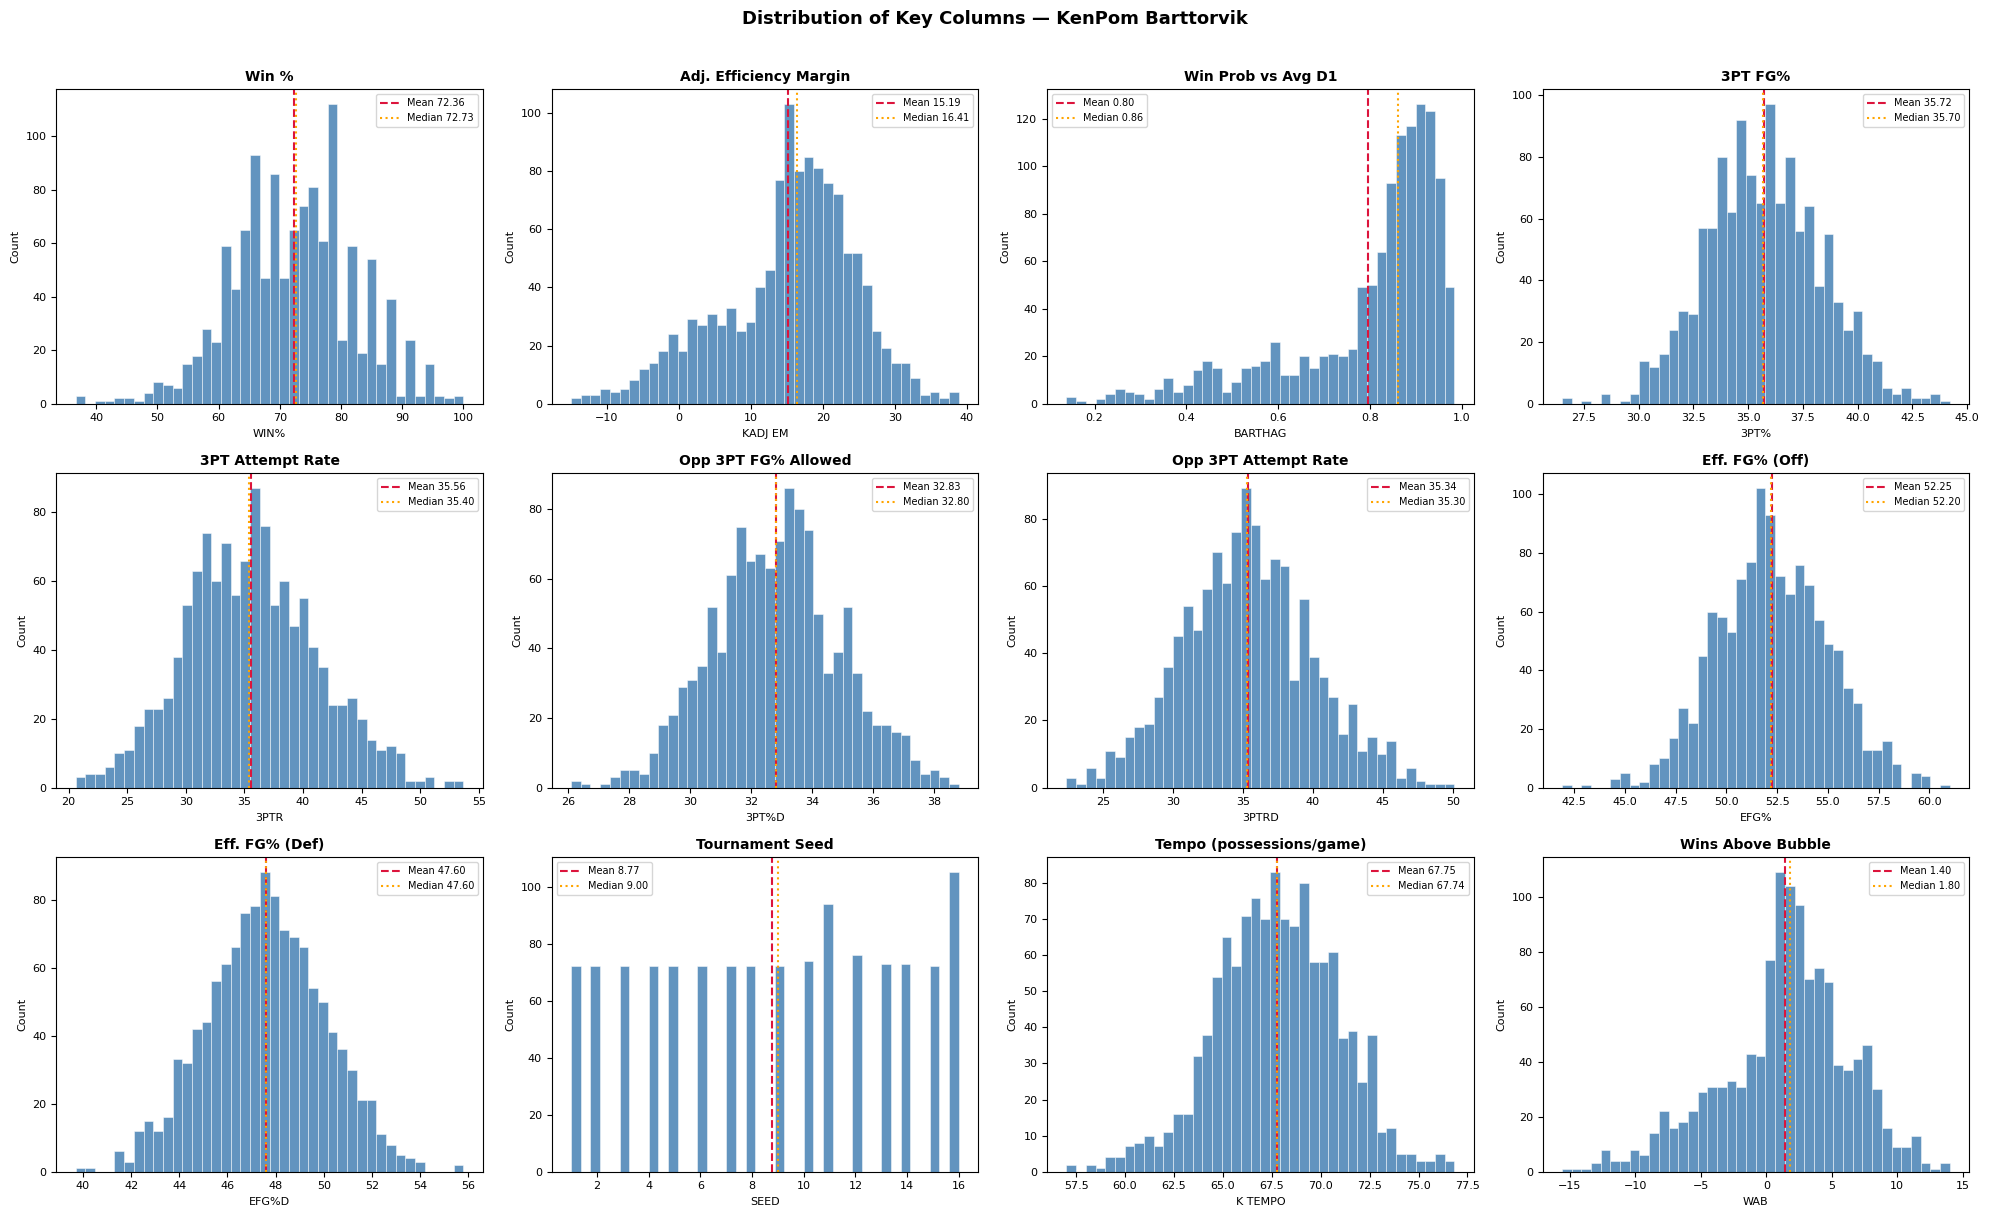

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_cols = [
    ('WIN%',     'Win %'),
    ('KADJ EM',  'Adj. Efficiency Margin'),
    ('BARTHAG',  'Win Prob vs Avg D1'),
    ('3PT%',     '3PT FG%'),
    ('3PTR',     '3PT Attempt Rate'),
    ('3PT%D',    'Opp 3PT FG% Allowed'),
    ('3PTRD',    'Opp 3PT Attempt Rate'),
    ('EFG%',     'Eff. FG% (Off)'),
    ('EFG%D',    'Eff. FG% (Def)'),
    ('SEED',     'Tournament Seed'),
    ('K TEMPO',  'Tempo (possessions/game)'),
    ('WAB',      'Wins Above Bubble'),
]

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for ax, (col, label) in zip(axes, plot_cols):
    data = kp[col].dropna()
    ax.hist(data, bins=40, color='steelblue', edgecolor='white', linewidth=0.4, alpha=0.85)
    ax.axvline(data.mean(),   color='crimson', linewidth=1.5, linestyle='--', label=f'Mean {data.mean():.2f}')
    ax.axvline(data.median(), color='orange',  linewidth=1.5, linestyle=':',  label=f'Median {data.median():.2f}')
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel(col, fontsize=8)
    ax.set_ylabel('Count', fontsize=8)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=8)

plt.suptitle('Distribution of Key Columns — KenPom Barttorvik', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

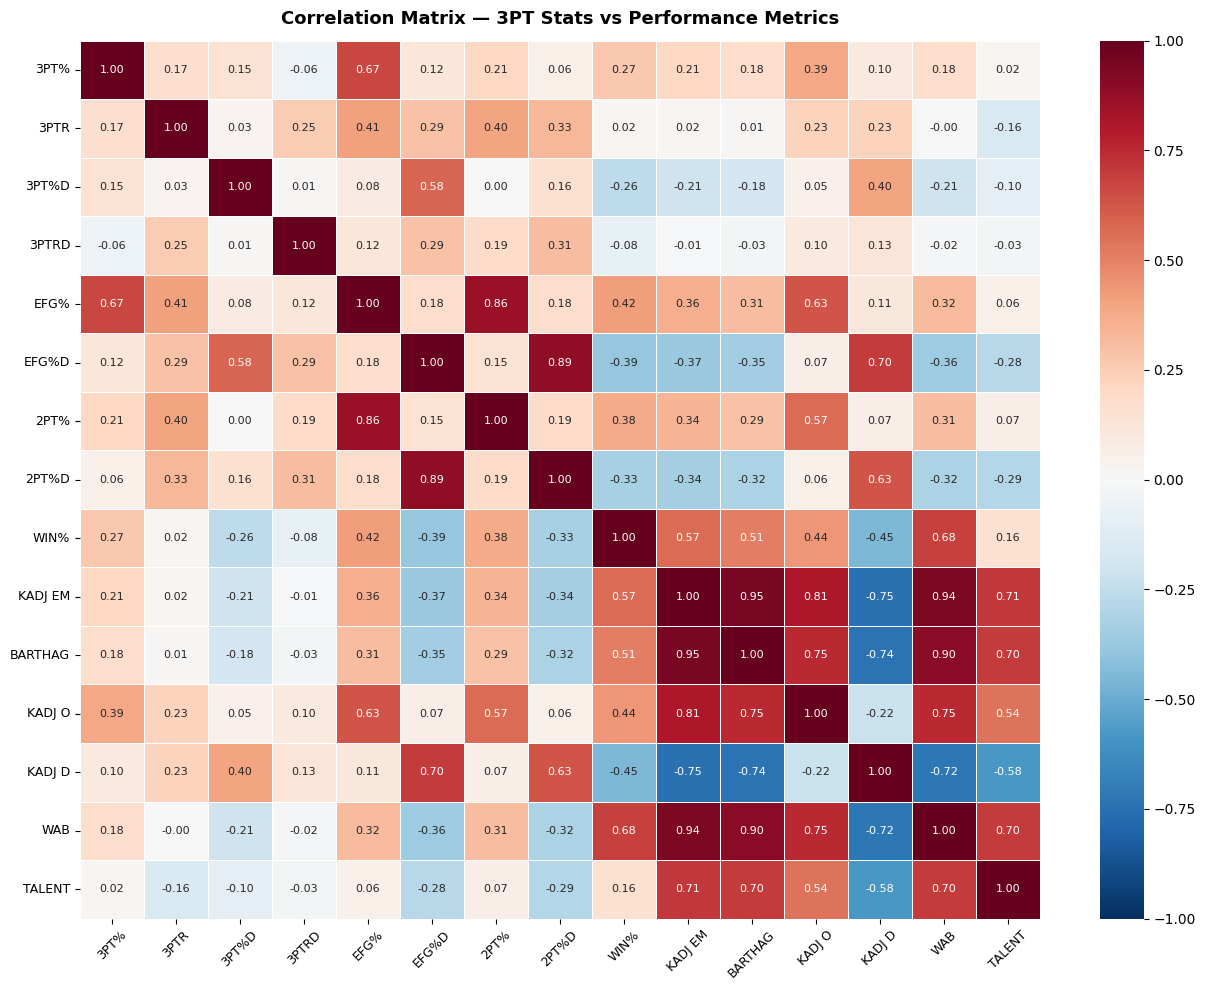

Top correlations with WIN%:
WAB        0.68
KADJ EM    0.57
BARTHAG    0.51
KADJ D    -0.45
KADJ O     0.44
EFG%       0.42
EFG%D     -0.39
2PT%       0.38
2PT%D     -0.33
3PT%       0.27
3PT%D     -0.26
TALENT     0.16
3PTRD     -0.08
3PTR       0.02


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_cols = [
    '3PT%', '3PTR', '3PT%D', '3PTRD',
    'EFG%', 'EFG%D', '2PT%', '2PT%D',
    'WIN%', 'KADJ EM', 'BARTHAG', 'KADJ O', 'KADJ D',
    'WAB', 'TALENT',
]

corr_matrix = kp[corr_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1,
    linewidths=0.4, linecolor='white',
    annot_kws={'size': 8}, ax=ax
)
ax.set_title('Correlation Matrix — 3PT Stats vs Performance Metrics', fontsize=13, fontweight='bold', pad=12)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)
plt.tight_layout()
plt.show()

print('Top correlations with WIN%:')
win_corr = corr_matrix['WIN%'].drop('WIN%').sort_values(key=abs, ascending=False)
print(win_corr.to_string())

## 3. Data Modelling

Select columns relevant to the question — 3PT stats, efficiency, tournament outcomes, pace, team context.

In [32]:
kp_cols = [
    'YEAR', 'TEAM ID', 'TEAM', 'CONF',
    'SEED', 'ROUND',
    'W', 'L', 'WIN%', 'GAMES',
    'KADJ EM',
    'KADJ O',
    'KADJ D',
    'BARTHAG',
    'BADJ EM',
    '3PT%',
    '3PTR',
    '3PT%D',
    '3PTRD',
    'EFG%',
    'EFG%D',
    '2PT%',  '2PT%D',
    '2PTR',  '2PTRD',
    'KADJ T',
    'K TEMPO',
    'PPPO',
    'FT%',
    'FTR',
    'TALENT',
    'EXP',
    'WAB',
    'ELITE SOS',
]

ss_cols = [
    'YEAR', 'TEAM ID',
    'THREES FG%',    'THREES SHARE',
    'THREES FG%D',   'THREES D SHARE',
    'CLOSE TWOS FG%',   'CLOSE TWOS SHARE',
    'FARTHER TWOS FG%', 'FARTHER TWOS SHARE',
    'DUNKS FG%',     'DUNKS SHARE',
]

kp_sel = kp[kp_cols].copy()
ss_sel = ss[ss_cols].copy()

print(f'KenPom selected : {kp_sel.shape[0]:,} rows  x  {kp_sel.shape[1]} columns')
print(f'Splits selected : {ss_sel.shape[0]:,} rows  x  {ss_sel.shape[1]} columns')

KenPom selected : 1,215 rows  x  34 columns
Splits selected : 1,085 rows  x  12 columns


## 4. Data Integration

Left join KenPom + Shooting Splits on `YEAR` + `TEAM ID`. Teams from 2008–2009 are kept but have no Shooting Splits columns.

In [33]:
df = kp_sel.merge(ss_sel, on=['YEAR', 'TEAM ID'], how='left')

print(f'Merged shape     : {df.shape[0]:,} rows  x  {df.shape[1]} columns')
print(f'Years covered    : {df["YEAR"].min()} â€“ {df["YEAR"].max()}')
print(f'Teams per year   : {df.groupby("YEAR").size().mean():.1f} (avg)')

Merged shape     : 1,215 rows  x  44 columns
Years covered    : 2008 â€“ 2026
Teams per year   : 67.5 (avg)


---
# PROCESS

## 5. Data Transformation

Remap `ROUND` from bracket size to ordinal 0–8 and add binary flags for tournament qualification and Sweet 16.

In [35]:
round_map = {0: 0, 68: 1, 64: 2, 32: 3, 16: 4, 8: 5, 4: 6, 2: 7, 1: 8}
df['tournament_round'] = df['ROUND'].map(round_map)

df['made_tournament'] = (df['ROUND'] >= 64).astype(int)

df['reached_s16'] = (df['tournament_round'] >= 4).astype(int)

df.rename(columns={'WIN%': 'win_pct'}, inplace=True)

print('tournament_round distribution:')
labels = {0:'No Tourney', 1:'First Four', 2:'R64', 3:'R32', 4:'S16', 5:'E8', 6:'F4', 7:'Final', 8:'Champion'}
print(df['tournament_round'].map(labels).value_counts().reindex(labels.values()))
print(f'\nTournament teams : {df["made_tournament"].sum():,} / {len(df):,}')
print(f'Sweet 16+ teams  : {df["reached_s16"].sum():,} / {len(df):,}')

tournament_round distribution:
tournament_round
No Tourney     68
First Four     59
R64           544
R32           272
S16           136
E8             68
F4             34
Final          17
Champion       17
Name: count, dtype: int64

Tournament teams : 603 / 1,215
Sweet 16+ teams  : 272 / 1,215


## 6. Data Cleaning

In [37]:
missing = df.isna().sum()
print('Columns with missing values:')
print(missing[missing > 0].to_string())

Columns with missing values:
THREES FG%            130
THREES SHARE          130
THREES FG%D           130
THREES D SHARE        130
CLOSE TWOS FG%        130
CLOSE TWOS SHARE      130
FARTHER TWOS FG%      130
FARTHER TWOS SHARE    130
DUNKS FG%             130
DUNKS SHARE           130


## 7. Feature Engineering

Quartile buckets for 3PT volume and efficiency, net differentials, 3PT value score, season shot totals.

In [39]:
df['three_rate_category'] = pd.qcut(
    df['3PTR'], q=4,
    labels=['Low (Q1)', 'Mid-Low (Q2)', 'Mid-High (Q3)', 'High (Q4)']
)

df['three_pct_category'] = pd.qcut(
    df['3PT%'], q=4,
    labels=['Low (Q1)', 'Mid-Low (Q2)', 'Mid-High (Q3)', 'High (Q4)']
)

print('3PT attempt rate quartiles:')
print(df['three_rate_category'].value_counts().sort_index())

3PT attempt rate quartiles:
three_rate_category
Low (Q1)         308
Mid-Low (Q2)     301
Mid-High (Q3)    306
High (Q4)        300
Name: count, dtype: int64


In [40]:
df['three_pct_net']  = df['3PT%']  - df['3PT%D']
df['three_rate_net'] = df['3PTR']  - df['3PTRD']

df['three_value'] = df['3PT%'] * 3 * (df['3PTR'] / 100)

print(df[['three_pct_net', 'three_rate_net', 'three_value']].describe().round(2))

       three_pct_net  three_rate_net  three_value
count        1215.00         1215.00      1215.00
mean            2.89            0.22        38.18
std             3.08            6.29         6.98
min            -7.40          -22.80        20.22
25%             0.85           -4.20        33.19
50%             2.90            0.10        37.94
75%             4.90            4.30        42.93
max            13.90           21.70        57.67


In [42]:
out_path = os.path.join(os.getcwd(), 'data', 'combined_ncaa.csv')
df.to_csv(out_path, index=False)

print(f'Saved  : {out_path}')
print(f'Shape  : {df.shape}')
print(f'\nAll columns:')
for i, c in enumerate(df.columns, 1):
    print(f'  {i:2d}. {c}')

Saved  : c:\Users\travi\OneDrive\Desktop\workspace\coursework\sc3021\ncaa\data\combined_ncaa.csv
Shape  : (1215, 57)

All columns:
   1. YEAR
   2. TEAM ID
   3. TEAM
   4. CONF
   5. SEED
   6. ROUND
   7. W
   8. L
   9. win_pct
  10. GAMES
  11. KADJ EM
  12. KADJ O
  13. KADJ D
  14. BARTHAG
  15. BADJ EM
  16. 3PT%
  17. 3PTR
  18. 3PT%D
  19. 3PTRD
  20. EFG%
  21. EFG%D
  22. 2PT%
  23. 2PT%D
  24. 2PTR
  25. 2PTRD
  26. KADJ T
  27. K TEMPO
  28. PPPO
  29. FT%
  30. FTR
  31. TALENT
  32. EXP
  33. WAB
  34. ELITE SOS
  35. THREES FG%
  36. THREES SHARE
  37. THREES FG%D
  38. THREES D SHARE
  39. CLOSE TWOS FG%
  40. CLOSE TWOS SHARE
  41. FARTHER TWOS FG%
  42. FARTHER TWOS SHARE
  43. DUNKS FG%
  44. DUNKS SHARE
  45. tournament_round
  46. made_tournament
  47. reached_s16
  48. has_shot_splits
  49. three_rate_category
  50. three_pct_category
  51. three_pct_net
  52. three_rate_net
  53. three_value
  54. 3PA
  55. 3PM
  56. 2PA
  57. 2PM


---
# Descriptive Analysis

## 1. Summary Statistics

In [43]:
key_cols = [
    '3PT%', '3PTR', '3PT%D', '3PTRD',
    'three_pct_net', 'three_rate_net', 'three_value',
    'win_pct', 'KADJ EM', 'BARTHAG', 'EFG%', 'EFG%D'
]

central = pd.DataFrame({
    'Mean'  : df[key_cols].mean().round(3),
    'Median': df[key_cols].median().round(3),
    'Mode'  : df[key_cols].mode().iloc[0].round(3),
})

print('Central Tendency — Key Columns')
central

Central Tendency — Key Columns


,Mean,Median,Mode
3PT%,35.718,35.700,34.900
3PTR,35.562,35.400,36.800
3PT%D,32.827,32.800,33.600
3PTRD,35.338,35.300,35.400
three_pct_net,2.891,2.900,2.000
three_rate_net,0.224,0.100,2.500
three_value,38.180,37.944,37.026
win_pct,72.362,72.727,78.125
KADJ EM,15.193,16.411,14.796
BARTHAG,0.796,0.860,0.895


### Spread

In [44]:
spread = pd.DataFrame({
    'Min'     : df[key_cols].min().round(3),
    'Max'     : df[key_cols].max().round(3),
    'Range'   : (df[key_cols].max() - df[key_cols].min()).round(3),
    'Std Dev' : df[key_cols].std().round(3),
    'Variance': df[key_cols].var().round(3),
    'IQR'     : (df[key_cols].quantile(0.75) - df[key_cols].quantile(0.25)).round(3),
})

print('Spread — Key Columns')
spread

Spread — Key Columns


,Min,Max,Range,Std Dev,Variance,IQR
3PT%,26.500,44.200,17.700,2.606,6.791,3.600
3PTR,20.600,53.700,33.100,5.594,31.292,7.700
3PT%D,26.100,38.800,12.700,2.076,4.310,2.700
3PTRD,22.400,50.100,27.700,4.636,21.496,6.000
three_pct_net,-7.400,13.900,21.300,3.078,9.474,4.050
three_rate_net,-22.800,21.700,44.500,6.294,39.615,8.500
three_value,20.225,57.674,37.449,6.978,48.690,9.737
win_pct,36.667,100.000,63.333,9.993,99.851,13.163
KADJ EM,-14.967,38.900,53.867,9.400,88.362,11.770
BARTHAG,0.139,0.983,0.844,0.172,0.030,0.177


In [45]:
print('=== Mean values: Tournament vs Non-Tournament ===')
print(df.groupby('made_tournament')[key_cols].mean().round(3).T.rename(
    columns={0: 'Non-Tournament', 1: 'Tournament'}
).to_string())

=== Mean values: Tournament vs Non-Tournament ===
made_tournament  Non-Tournament  Tournament
3PT%                     35.867      35.566
3PTR                     35.698      35.425
3PT%D                    32.573      33.085
3PTRD                    35.470      35.205
three_pct_net             3.294       2.481
three_rate_net            0.228       0.220
three_value              38.476      37.880
win_pct                  75.275      69.405
KADJ EM                  19.942      10.373
BARTHAG                   0.874       0.716
EFG%                     52.699      51.797
EFG%D                    47.240      47.969


## 2. Aggregation

In [46]:
round_labels = {
    0:'No Tourney', 1:'First Four', 2:'R64',
    3:'R32', 4:'S16', 5:'E8', 6:'F4', 7:'Final', 8:'Champion'
}
stage_order = list(round_labels.values())

stage_agg = (
    df.copy()
    .assign(Stage=df['tournament_round'].map(round_labels))
    .groupby('Stage')[['3PT%', '3PTR', '3PT%D', '3PTRD', 'win_pct', 'KADJ EM']]
    .agg(['mean', 'median', 'std'])
    .round(2)
    .reindex(stage_order)
)

print('Aggregation by Tournament Stage:')
stage_agg

Aggregation by Tournament Stage:


3PT%                3PTR               3PT%D               3PTRD  \
             mean median   std   mean median   std   mean median   std   mean   
Stage                                                                           
No Tourney  35.38  35.25  2.01  40.21  40.50  6.11  32.60  32.55  1.70  39.37   
First Four  34.56  34.50  3.02  35.15  35.80  5.63  32.80  32.70  2.14  35.30   
R64         35.68  35.60  2.63  35.45  35.25  5.42  33.12  33.10  2.07  35.19   
R32         35.63  35.60  2.53  35.16  35.20  5.53  32.71  32.75  1.91  34.89   
S16         36.20  35.95  2.59  35.11  35.00  5.24  32.57  32.60  2.38  35.26   
E8          36.00  35.75  2.68  34.80  34.55  4.80  32.39  32.65  2.15  35.08   
F4          36.34  36.75  2.45  36.01  35.40  6.86  32.25  32.40  1.98  35.32   
Final       36.04  36.20  2.33  34.16  34.90  4.47  32.37  32.00  2.18  34.55   
Champion    37.24  37.10  2.54  35.50  33.80  6.28  31.89  32.10  2.22  33.65   

                        win_pct               KADJ EM                
           median   std    mean median    std    mean median    std  
Stage                                                                
No Tourney  39.30  4.07   72.53  71.23  10.63   16.84  19.50  12.23  
First Four  35.50  4.60   60.94  62.50   9.93    3.95   2.91  10.83  
R64         35.15  4.71   70.32  70.00   9.04   11.07  12.94   8.17  
R32         34.75  4.15   73.32  72.73   9.08   17.67  17.98   5.89  
S16         35.45  5.18   75.60  75.76   8.90   21.46  22.27   5.37  
E8          35.10  3.89   78.52  78.79   8.17   23.53  24.19   5.63  
F4          35.40  4.20   79.19  78.79   9.80   23.42  23.52   6.81  
Final       35.00  4.51   84.03  81.82   8.85   26.02  26.75   6.46  
Champion    33.50  4.25   85.50  87.10   6.02   29.25  29.50   4.56

In [47]:
rate_agg = (
    df.groupby('three_rate_category', observed=True)
    [['3PT%', 'win_pct', 'KADJ EM', 'BARTHAG', 'made_tournament', 'reached_s16']]
    .agg(['mean', 'median', 'count'])
    .round(3)
)

print('Aggregation by 3PT Attempt Rate Quartile:')
rate_agg

Aggregation by 3PT Attempt Rate Quartile:


3PT%              win_pct               KADJ EM  \
                       mean median count    mean  median count    mean   
three_rate_category                                                      
Low (Q1)             34.917  34.70   308  72.128  72.727   308  14.571   
Mid-Low (Q2)         35.829  35.80   301  72.220  72.727   301  15.834   
Mid-High (Q3)        35.934  35.95   306  72.966  74.194   306  15.028   
High (Q4)            36.207  36.10   300  72.128  71.875   300  15.356   

                                  BARTHAG              made_tournament         \
                     median count    mean median count            mean median   
three_rate_category                                                             
Low (Q1)             16.219   308   0.782  0.860   308           0.510    1.0   
Mid-Low (Q2)         17.153   301   0.810  0.868   301           0.502    1.0   
Mid-High (Q3)        15.931   306   0.796  0.855   306           0.493    0.0   
High (Q4)            16.422   300   0.795  0.855   300           0.480    0.0   

                          reached_s16               
                    count        mean median count  
three_rate_category                                 
Low (Q1)              308       0.218    0.0   308  
Mid-Low (Q2)          301       0.259    0.0   301  
Mid-High (Q3)         306       0.235    0.0   306  
High (Q4)             300       0.183    0.0   300

### Rolling Average

In [49]:
yearly_avg = df.groupby('YEAR')[['3PT%', '3PTR', '3PT%D', '3PTRD',
                                   'EFG%', 'win_pct', 'KADJ EM']].mean().round(3)

rolling_3yr = yearly_avg.rolling(window=3, min_periods=1).mean().round(3)
rolling_3yr.columns = [f'{c} (3yr roll)' for c in rolling_3yr.columns]

roll_display = pd.concat([yearly_avg[['3PT%', '3PTR', '3PT%D', '3PTRD']],
                           rolling_3yr[['3PT% (3yr roll)', '3PTR (3yr roll)']]], axis=1)

print('Yearly averages + 3-year rolling mean:')
roll_display

Yearly averages + 3-year rolling mean:


,3PT%,3PTR,3PT%D,3PTRD,3PT% (3yr roll),3PTR (3yr roll)
YEAR,,,,,,
2008,36.838,34.057,33.305,33.805,36.838,34.057
2009,35.732,32.445,33.089,33.085,36.285,33.251
2010,35.740,31.934,32.428,32.446,36.103,32.812
2011,35.869,33.156,32.991,32.478,35.780,32.512
2012,35.499,32.563,32.719,31.690,35.703,32.551
2013,35.372,32.993,32.594,32.691,35.580,32.904
2014,35.765,32.451,32.884,32.126,35.545,32.669
2015,35.971,33.597,32.932,33.535,35.703,33.014
2016,36.193,34.732,33.516,34.610,35.976,33.593


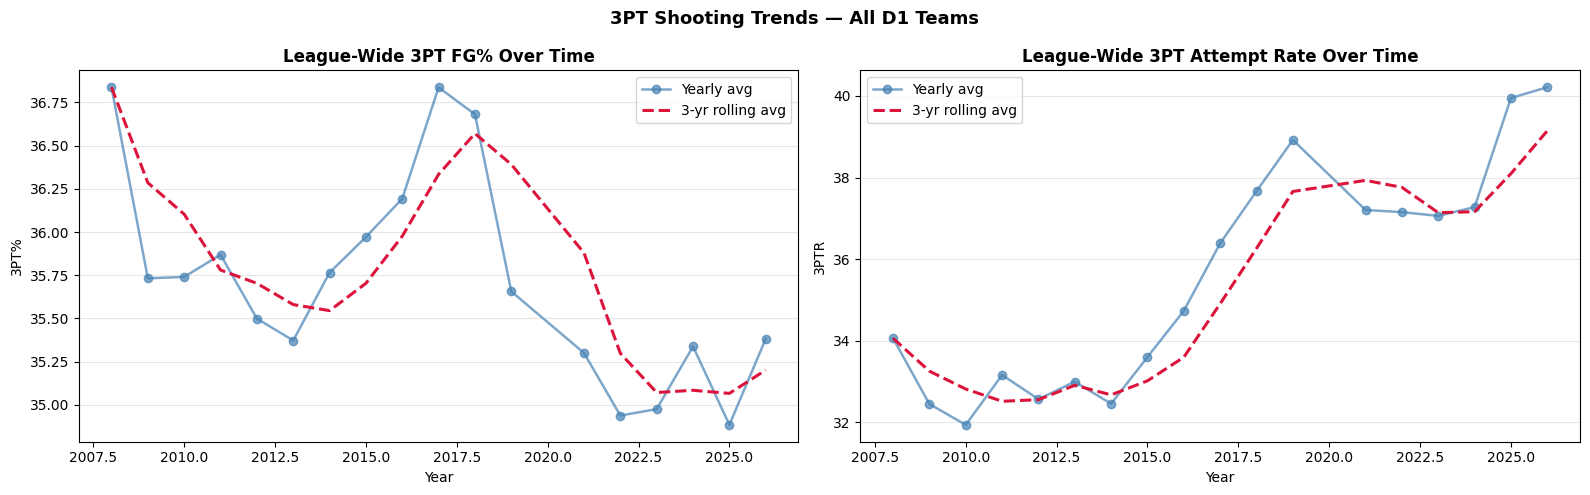

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, col, title in zip(axes,
    ['3PT%', '3PTR'],
    ['League-Wide 3PT FG% Over Time', 'League-Wide 3PT Attempt Rate Over Time']):

    ax.plot(yearly_avg.index, yearly_avg[col],
            marker='o', color='steelblue', linewidth=1.8, alpha=0.7, label='Yearly avg')
    ax.plot(rolling_3yr.index, rolling_3yr[f'{col} (3yr roll)'],
            color='crimson', linewidth=2.2, linestyle='--', label='3-yr rolling avg')
    ax.set_xlabel('Year')
    ax.set_ylabel(col)
    ax.set_title(title, fontweight='bold')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('3PT Shooting Trends — All D1 Teams', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

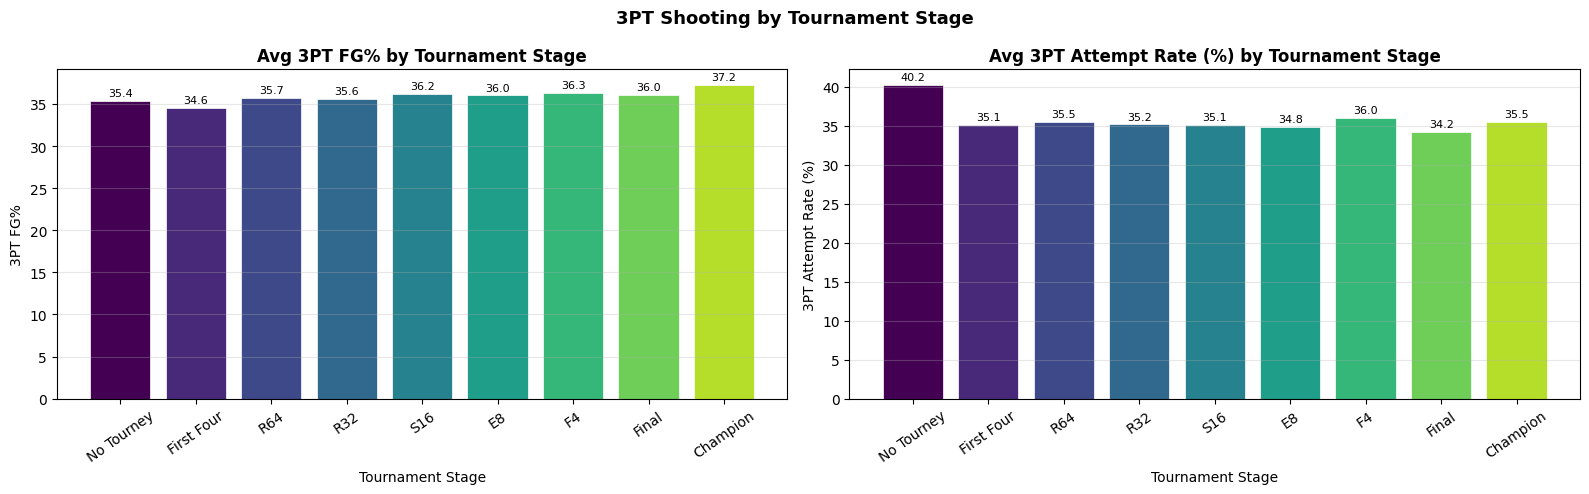

In [51]:
stage_means = (
    df.copy()
    .assign(Stage=df['tournament_round'].map(round_labels))
    .groupby('Stage', observed=True)[['3PT%', '3PTR']]
    .mean()
    .reindex(stage_order)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors = plt.cm.viridis([i / len(stage_order) for i in range(len(stage_order))])

for ax, col, ylabel in zip(axes, ['3PT%', '3PTR'], ['3PT FG%', '3PT Attempt Rate (%)']):
    bars = ax.bar(stage_means.index, stage_means[col], color=colors, edgecolor='white', linewidth=0.5)
    ax.set_xlabel('Tournament Stage')
    ax.set_ylabel(ylabel)
    ax.set_title(f'Avg {ylabel} by Tournament Stage', fontweight='bold')
    ax.tick_params(axis='x', rotation=35)
    ax.bar_label(bars, fmt='%.1f', fontsize=8, padding=2)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('3PT Shooting by Tournament Stage', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

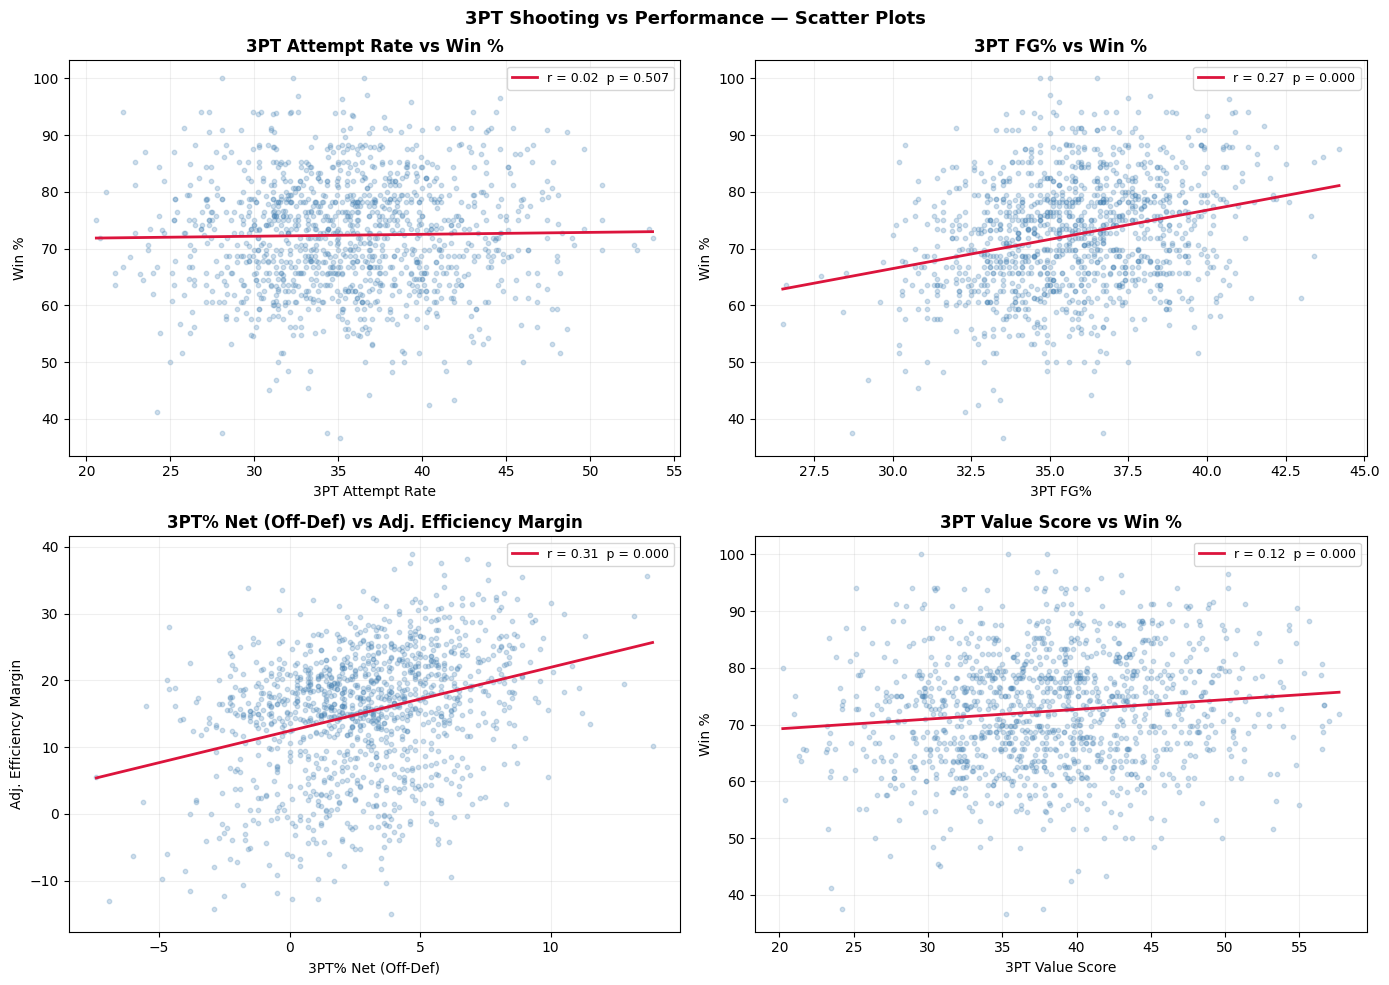

In [52]:
from scipy import stats

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

pairs = [
    ('3PTR',           'win_pct',  '3PT Attempt Rate', 'Win %'),
    ('3PT%',           'win_pct',  '3PT FG%',          'Win %'),
    ('three_pct_net',  'KADJ EM',  '3PT% Net (Off-Def)', 'Adj. Efficiency Margin'),
    ('three_value',    'win_pct',  '3PT Value Score',  'Win %'),
]

for ax, (xcol, ycol, xlabel, ylabel) in zip(axes, pairs):
    data = df[[xcol, ycol]].dropna()
    ax.scatter(data[xcol], data[ycol], alpha=0.25, s=10, color='steelblue')
    slope, intercept, r, p, _ = stats.linregress(data[xcol], data[ycol])
    x_line = [data[xcol].min(), data[xcol].max()]
    y_line = [slope * x + intercept for x in x_line]
    ax.plot(x_line, y_line, color='crimson', linewidth=2,
            label=f'r = {r:.2f}  p = {p:.3f}')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(f'{xlabel} vs {ylabel}', fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.2)

plt.suptitle('3PT Shooting vs Performance — Scatter Plots', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Histograms and Box Plots

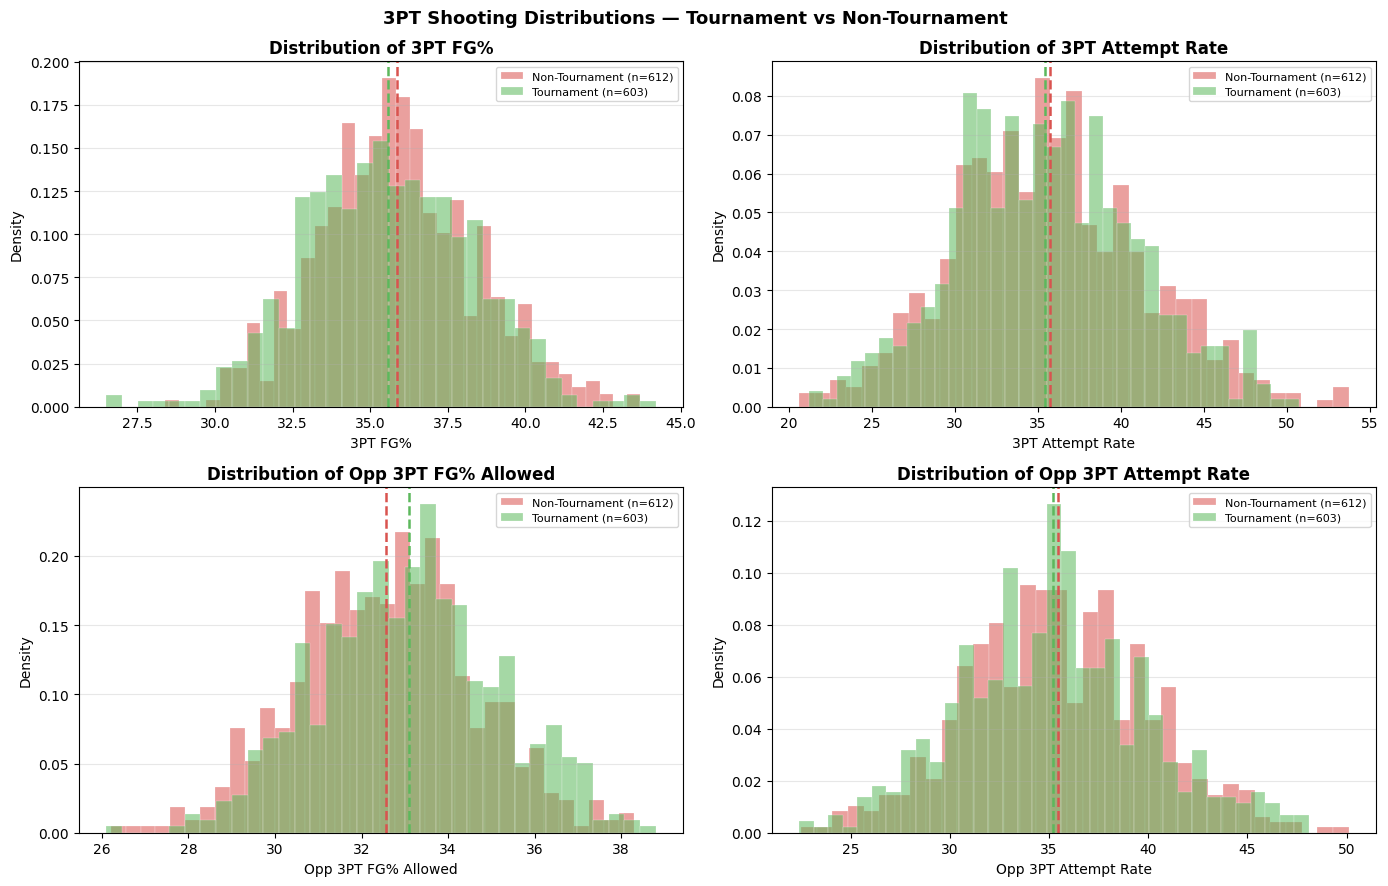

In [53]:
hist_cols = [
    ('3PT%',  '3PT FG%'),
    ('3PTR',  '3PT Attempt Rate'),
    ('3PT%D', 'Opp 3PT FG% Allowed'),
    ('3PTRD', 'Opp 3PT Attempt Rate'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

palette = {0: ('#d9534f', 'Non-Tournament'), 1: ('#5cb85c', 'Tournament')}

for ax, (col, label) in zip(axes, hist_cols):
    for status, (color, name) in palette.items():
        data = df[df['made_tournament'] == status][col].dropna()
        ax.hist(data, bins=35, color=color, alpha=0.55, edgecolor='white',
                linewidth=0.3, label=f'{name} (n={len(data):,})', density=True)
        ax.axvline(data.mean(), color=color, linewidth=1.8, linestyle='--')
    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.set_title(f'Distribution of {label}', fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('3PT Shooting Distributions — Tournament vs Non-Tournament', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\travi\AppData\Local\Temp\ipykernel_30532\3803831139.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Stage', y=col, data=plot_df, order=stage_order,
C:\Users\travi\AppData\Local\Temp\ipykernel_30532\3803831139.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Stage', y=col, data=plot_df, order=stage_order,
C:\Users\travi\AppData\Local\Temp\ipykernel_30532\3803831139.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Stage', y=col, data=plot_df, order=stage_order,
C:\Users\travi\AppData\Local\Temp\ipykernel_30532\38

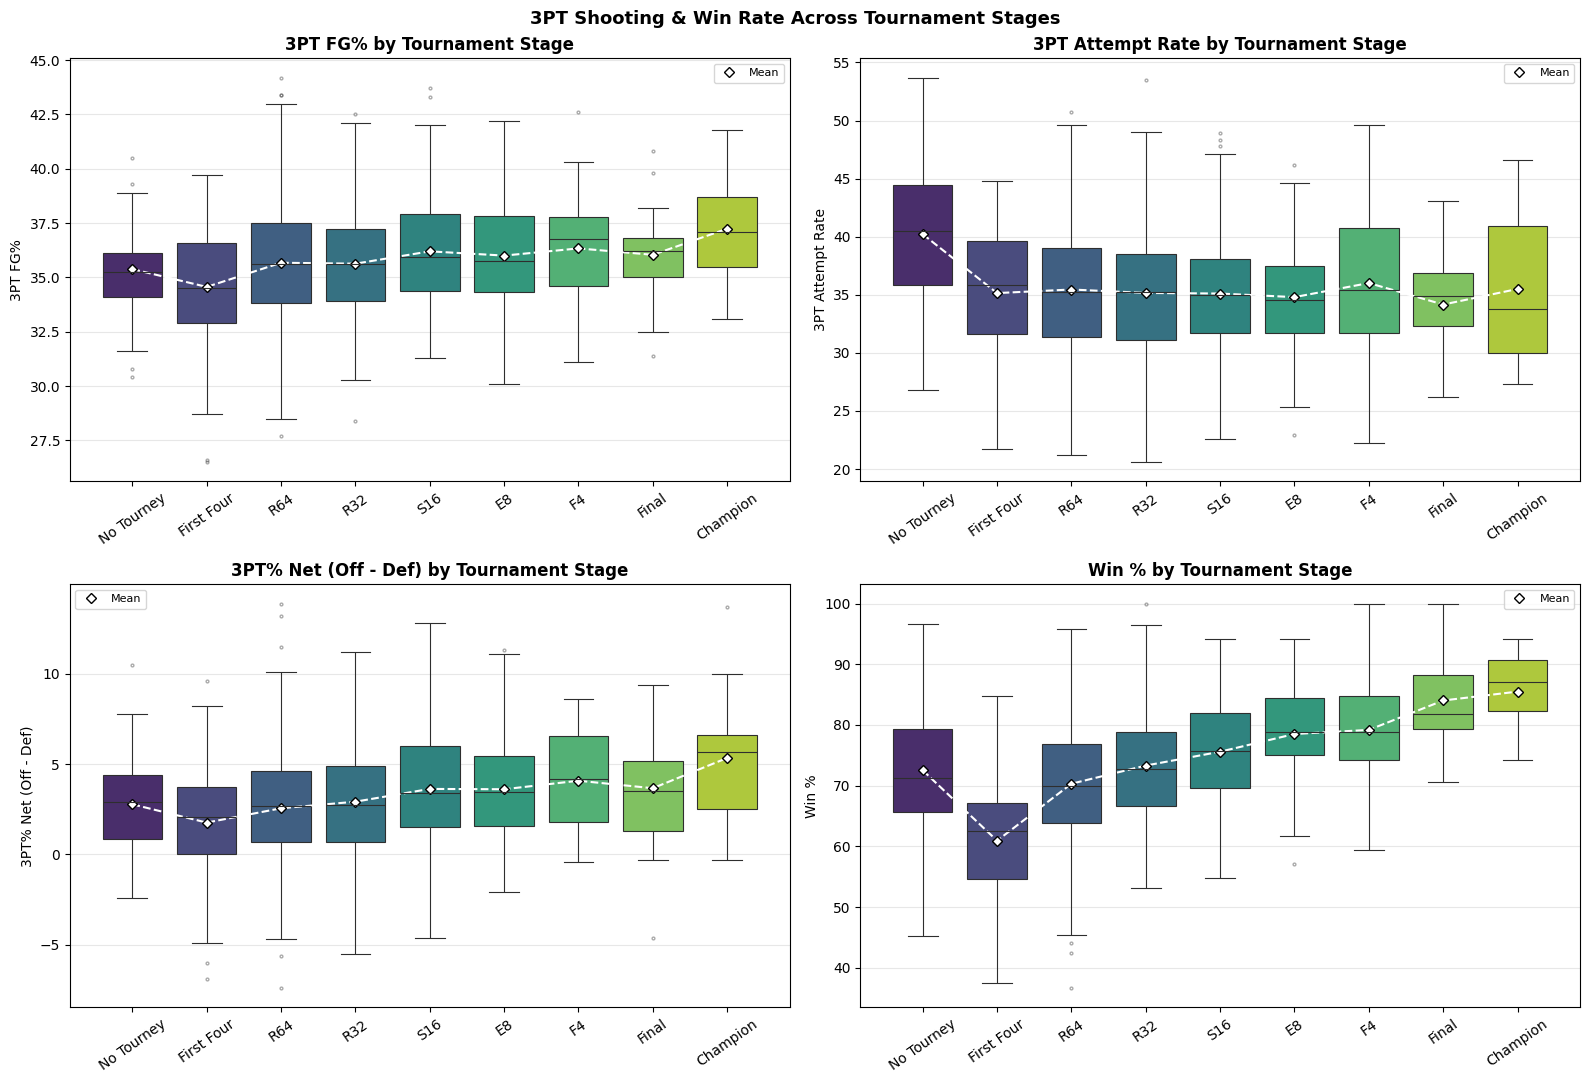

In [54]:
box_cols = [
    ('3PT%',  '3PT FG%'),
    ('3PTR',  '3PT Attempt Rate'),
    ('three_pct_net', '3PT% Net (Off - Def)'),
    ('win_pct', 'Win %'),
]

plot_df = df.copy()
plot_df['Stage'] = pd.Categorical(
    df['tournament_round'].map(round_labels),
    categories=stage_order, ordered=True
)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()

for ax, (col, label) in zip(axes, box_cols):
    sns.boxplot(x='Stage', y=col, data=plot_df, order=stage_order,
                palette='viridis', ax=ax, linewidth=0.8,
                flierprops=dict(marker='o', markersize=2, alpha=0.4))
    means = plot_df.groupby('Stage', observed=True)[col].mean().reindex(stage_order)
    ax.plot(range(len(stage_order)), means.values, 'D--',
            color='white', markersize=5, markeredgecolor='black',
            linewidth=1.5, label='Mean')
    ax.set_xlabel('')
    ax.set_ylabel(label)
    ax.set_title(f'{label} by Tournament Stage', fontweight='bold')
    ax.tick_params(axis='x', rotation=35)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('3PT Shooting & Win Rate Across Tournament Stages', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Time Series

### Trend

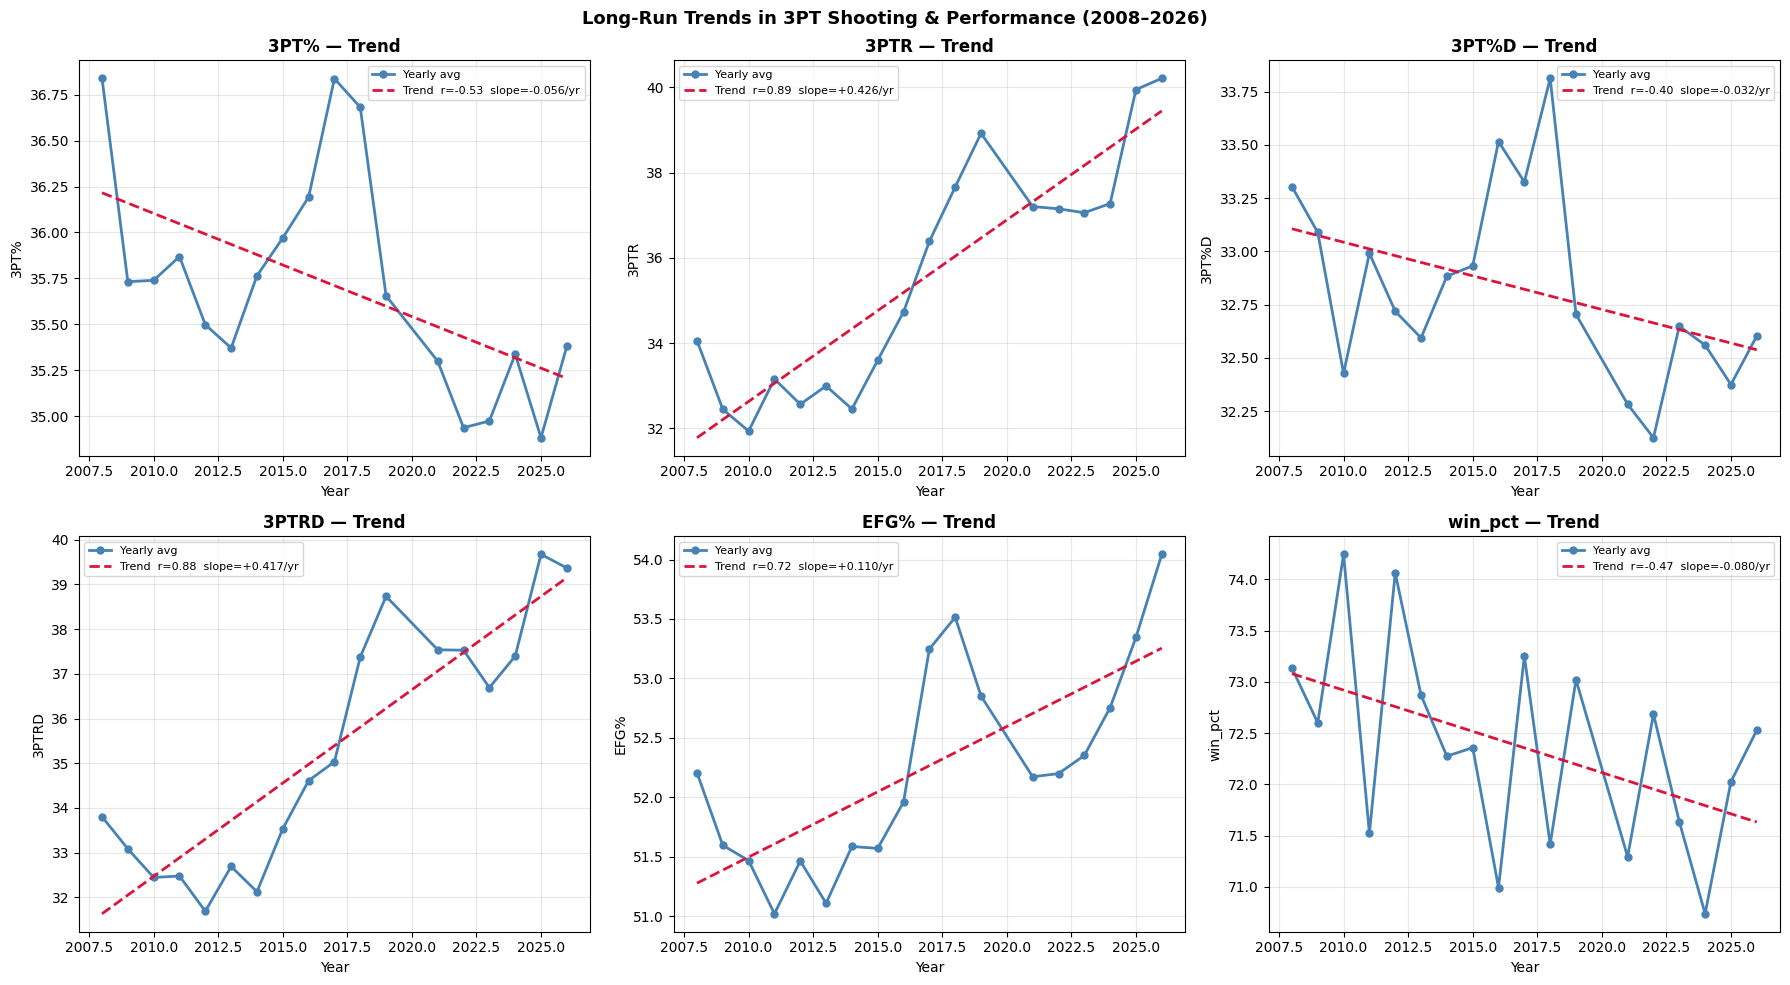

In [55]:
from scipy import stats as scipy_stats

ts_cols = ['3PT%', '3PTR', '3PT%D', '3PTRD', 'EFG%', 'win_pct']
ts = df.groupby('YEAR')[ts_cols].mean()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, ts_cols):
    years = ts.index.values
    values = ts[col].values

    slope, intercept, r, p, _ = scipy_stats.linregress(years, values)
    trend_line = slope * years + intercept

    ax.plot(years, values, marker='o', color='steelblue',
            linewidth=2, markersize=5, label='Yearly avg')
    ax.plot(years, trend_line, color='crimson', linewidth=2,
            linestyle='--', label=f'Trend  r={r:.2f}  slope={slope:+.3f}/yr')
    ax.set_xlabel('Year')
    ax.set_ylabel(col)
    ax.set_title(f'{col} — Trend', fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Long-Run Trends in 3PT Shooting & Performance (2008–2026)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
# Diagnostic Analysis

## Observation

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as scipy_stats
import warnings
warnings.filterwarnings('ignore')

tourney     = df[df['made_tournament'] == 1]
non_tourney = df[df['made_tournament'] == 0]

obs_cols = ['3PT%', '3PTR', '3PT%D', '3PTRD', 'win_pct', 'KADJ EM']
obs_summary = pd.DataFrame({
    'Non-Tournament mean': non_tourney[obs_cols].mean().round(3),
    'Tournament mean'    : tourney[obs_cols].mean().round(3),
    'Difference'         : (tourney[obs_cols].mean() - non_tourney[obs_cols].mean()).round(3),
})
print('Mean comparison — Tournament vs Non-Tournament teams:')
obs_summary

Mean comparison — Tournament vs Non-Tournament teams:


,Non-Tournament mean,Tournament mean,Difference
3PT%,35.867,35.566,-0.301
3PTR,35.698,35.425,-0.273
3PT%D,32.573,33.085,0.512
3PTRD,35.470,35.205,-0.265
win_pct,75.275,69.405,-5.870
KADJ EM,19.942,10.373,-9.568


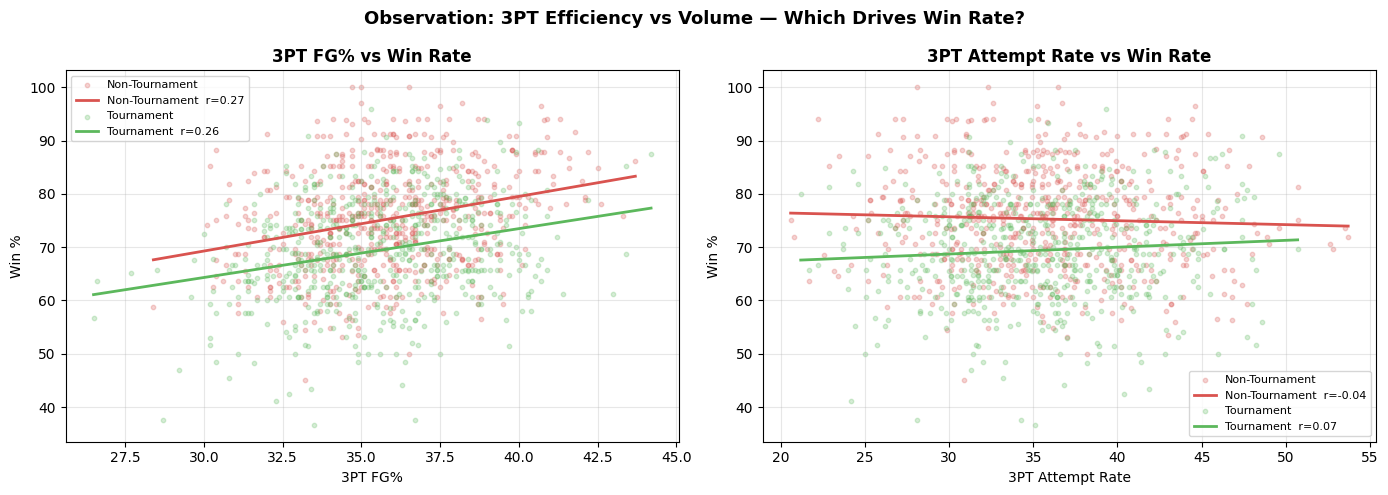

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

palette = {0: ('#d9534f', 'Non-Tournament'), 1: ('#5cb85c', 'Tournament')}

for ax, (xcol, xlabel) in zip(axes, [('3PT%', '3PT FG%'), ('3PTR', '3PT Attempt Rate')]):
    for status, (color, label) in palette.items():
        sub = df[df['made_tournament'] == status]
        ax.scatter(sub[xcol], sub['win_pct'], color=color, alpha=0.25, s=10, label=label)
        slope, intercept, r, p, _ = scipy_stats.linregress(
            sub[xcol].dropna(), sub.loc[sub[xcol].notna(), 'win_pct'])
        x_line = np.linspace(sub[xcol].min(), sub[xcol].max(), 100)
        ax.plot(x_line, slope * x_line + intercept, color=color, linewidth=2,
                label=f'{label}  r={r:.2f}')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Win %')
    ax.set_title(f'{xlabel} vs Win Rate', fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Observation: 3PT Efficiency vs Volume — Which Drives Win Rate?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Observation Statement

> **3-point shooting efficiency (3PT%) is positively correlated with win rate — but 3-point attempt rate (3PTR) shows little to no relationship with win rate.**
>
> In other words: shooting 3-pointers *accurately* separates winners from losers, but shooting *more* 3-pointers does not.

This is counter-intuitive. If 3-pointers are worth more points, why doesn't attempting more of them lead to more wins?

The following diagnostic analysis investigates *why* this pattern exists.

## 1. Relationship and Dependency Analysis

### Correlation — Pearson & Spearman

Cells greyed out are not statistically significant (p > 0.05).

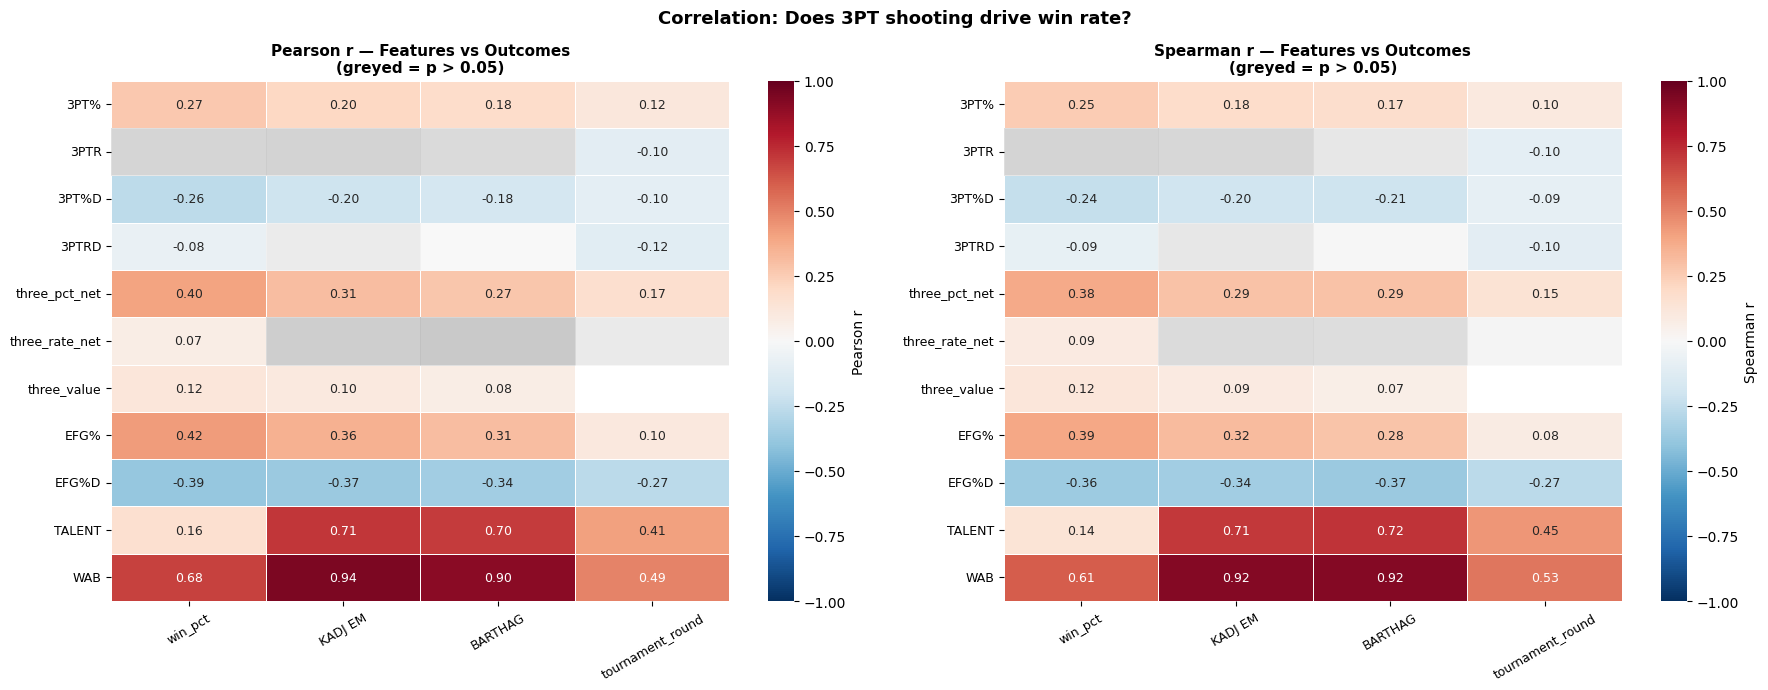

In [61]:
target_cols  = ['win_pct', 'KADJ EM', 'BARTHAG', 'tournament_round']
feature_cols = ['3PT%', '3PTR', '3PT%D', '3PTRD',
                'three_pct_net', 'three_rate_net', 'three_value',
                'EFG%', 'EFG%D', 'TALENT', 'WAB']

clean = df[feature_cols + target_cols].dropna()

pearson_r  = pd.DataFrame(index=feature_cols, columns=target_cols, dtype=float)
pearson_p  = pd.DataFrame(index=feature_cols, columns=target_cols, dtype=float)
spearman_r = pd.DataFrame(index=feature_cols, columns=target_cols, dtype=float)
spearman_p = pd.DataFrame(index=feature_cols, columns=target_cols, dtype=float)

for feat in feature_cols:
    for tgt in target_cols:
        pr, pp = scipy_stats.pearsonr(clean[feat], clean[tgt])
        sr, sp = scipy_stats.spearmanr(clean[feat], clean[tgt])
        pearson_r.loc[feat, tgt]  = round(pr, 3)
        pearson_p.loc[feat, tgt]  = round(pp, 4)
        spearman_r.loc[feat, tgt] = round(sr, 3)
        spearman_p.loc[feat, tgt] = round(sp, 4)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, mat, pmat, title in zip(axes,
    [pearson_r, spearman_r], [pearson_p, spearman_p],
    ['Pearson r', 'Spearman r']):

    sig_mask = pmat > 0.05
    sns.heatmap(mat.astype(float), annot=True, fmt='.2f', cmap='RdBu_r',
                center=0, vmin=-1, vmax=1, linewidths=0.4, linecolor='white',
                annot_kws={'size': 9}, ax=ax,
                mask=sig_mask, cbar_kws={'label': title})
    sns.heatmap(mat.astype(float), annot=False, cmap='Greys',
                center=0, alpha=0.25, linewidths=0.4, linecolor='white',
                ax=ax, mask=~sig_mask, cbar=False)
    ax.set_title(f'{title} — Features vs Outcomes\n(greyed = p > 0.05)',
                 fontweight='bold', fontsize=11)
    ax.tick_params(axis='x', rotation=30, labelsize=9)
    ax.tick_params(axis='y', rotation=0, labelsize=9)

plt.suptitle('Correlation: Does 3PT shooting drive win rate?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [62]:
compare = pd.DataFrame({
    'Pearson r'   : pearson_r['win_pct'],
    'Pearson p'   : pearson_p['win_pct'],
    'Spearman r'  : spearman_r['win_pct'],
    'Spearman p'  : spearman_p['win_pct'],
    'Sig (p<0.05)': (pearson_p['win_pct'] < 0.05).map({True: 'Yes', False: 'No'})
}).sort_values('Pearson r', key=abs, ascending=False)

print('Pearson vs Spearman — correlation with win_pct:')
print()
print('Key finding: 3PT% r =', pearson_r.loc['3PT%', 'win_pct'],
      '| 3PTR r =', pearson_r.loc['3PTR', 'win_pct'])
print('This confirms the observation: efficiency correlates with wins; volume does not.')
compare

Pearson vs Spearman — correlation with win_pct:

Key finding: 3PT% r = 0.268 | 3PTR r = 0.019
This confirms the observation: efficiency correlates with wins; volume does not.


,Pearson r,Pearson p,Spearman r,Spearman p,Sig (p<0.05)
WAB,0.680,0.0000,0.608,0.0000,Yes
EFG%,0.422,0.0000,0.385,0.0000,Yes
three_pct_net,0.402,0.0000,0.378,0.0000,Yes
EFG%D,-0.388,0.0000,-0.365,0.0000,Yes
3PT%,0.268,0.0000,0.251,0.0000,Yes
3PT%D,-0.259,0.0000,-0.240,0.0000,Yes
TALENT,0.159,0.0000,0.136,0.0000,Yes
three_value,0.120,0.0000,0.121,0.0000,Yes
3PTRD,-0.078,0.0066,-0.085,0.0030,Yes
three_rate_net,0.074,0.0095,0.087,0.0025,Yes


### Regression Analysis

#### Linear Regression

In [63]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score, mean_squared_error

reg_data = df[['3PT%', '3PTR', '3PT%D', '3PTRD',
               'three_pct_net', 'EFG%', 'EFG%D', 'TALENT', 'win_pct', 'KADJ EM']].dropna()

y = reg_data['win_pct']
print(f'Regression dataset: {len(reg_data):,} rows')

Regression dataset: 1,215 rows


In [64]:
features = ['3PT%', '3PTR', '3PT%D', '3PTRD', 'three_pct_net', 'EFG%', 'EFG%D']
results  = []

for feat in features:
    x   = reg_data[[feat]]
    lr  = LinearRegression().fit(x, y)
    yp  = lr.predict(x)
    r2  = r2_score(y, yp)
    rmse = np.sqrt(mean_squared_error(y, yp))
    results.append({
        'Feature'  : feat,
        'Coeff'    : round(lr.coef_[0], 4),
        'Intercept': round(lr.intercept_, 3),
        'R²'       : round(r2, 4),
        'RMSE'     : round(rmse, 4),
        'Interpet' : f'+{lr.coef_[0]:.3f}% win rate per 1-unit increase in {feat}'
                      if lr.coef_[0] > 0
                      else f'{lr.coef_[0]:.3f}% win rate per 1-unit increase in {feat}'
    })

simple_df = pd.DataFrame(results).sort_values('R²', ascending=False)
print('Simple Linear Regression vs win_pct:')
simple_df

Simple Linear Regression vs win_pct:


,Feature,Coeff,Intercept,R²,RMSE,Interpet
5,EFG%,1.5439,-8.310,0.1785,9.0534,+1.544% win rate per 1-unit increase in EFG%
4,three_pct_net,1.3060,68.587,0.1618,9.1446,+1.306% win rate per 1-unit increase in three_...
6,EFG%D,-1.5999,148.521,0.1504,9.2069,-1.600% win rate per 1-unit increase in EFG%D
0,3PT%,1.0294,35.593,0.0721,9.6218,+1.029% win rate per 1-unit increase in 3PT%
2,3PT%D,-1.2489,113.359,0.0673,9.6463,-1.249% win rate per 1-unit increase in 3PT%D
3,3PTRD,-0.1679,78.297,0.0061,9.9580,-0.168% win rate per 1-unit increase in 3PTRD
1,3PTR,0.0340,71.152,0.0004,9.9866,+0.034% win rate per 1-unit increase in 3PTR


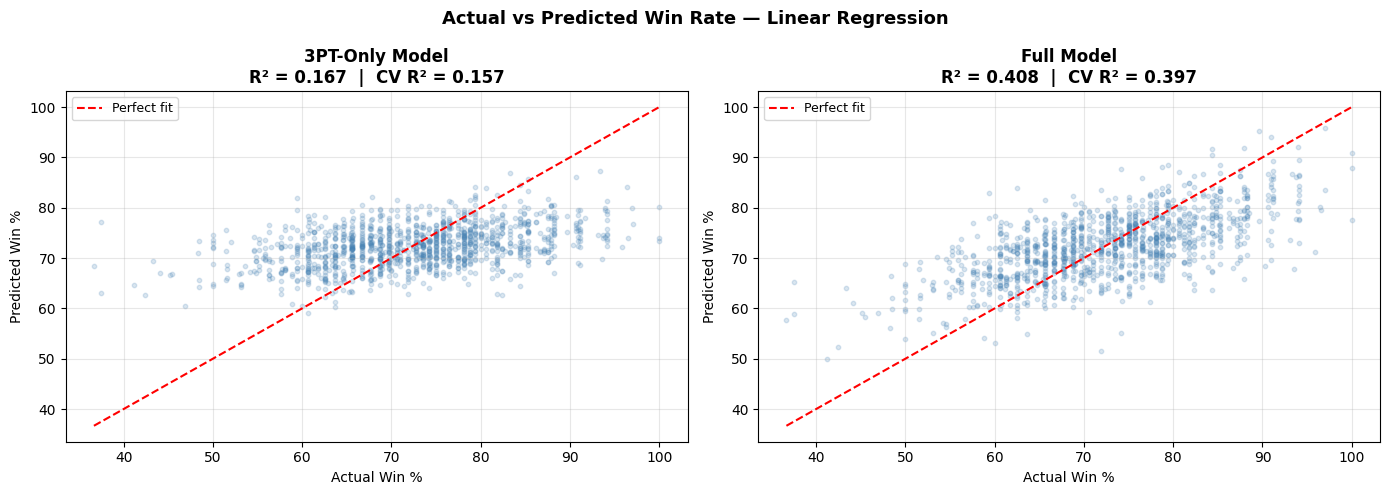

Coefficients:


,3PT-Only coeff,Full coeff
3PT%,1.2014,-0.1664
3PT%D,-1.4703,-0.1723
3PTR,-0.0206,-0.1381
3PTRD,-0.1134,0.0087
EFG%,NaN,2.0771
EFG%D,NaN,-1.8543
TALENT,NaN,-0.0060
three_pct_net,NaN,0.0059


In [65]:
X_3pt = reg_data[['3PT%', '3PTR', '3PT%D', '3PTRD']]
X_full = reg_data[['3PT%', '3PTR', '3PT%D', '3PTRD', 'three_pct_net', 'EFG%', 'EFG%D', 'TALENT']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (label, X) in zip(axes, [('3PT-Only Model', X_3pt), ('Full Model', X_full)]):
    lr    = LinearRegression().fit(X, y)
    y_pred = lr.predict(X)
    cv_r2 = cross_val_score(lr, X, y, cv=5, scoring='r2').mean()
    r2    = r2_score(y, y_pred)

    ax.scatter(y, y_pred, alpha=0.2, s=10, color='steelblue')
    lim = [y.min(), y.max()]
    ax.plot(lim, lim, 'r--', linewidth=1.5, label='Perfect fit')
    ax.set_xlabel('Actual Win %')
    ax.set_ylabel('Predicted Win %')
    ax.set_title(f'{label}\nR² = {r2:.3f}  |  CV R² = {cv_r2:.3f}', fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('Actual vs Predicted Win Rate — Linear Regression', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

lr_3pt  = LinearRegression().fit(X_3pt, y)
lr_full = LinearRegression().fit(X_full, y)
coef_df = pd.DataFrame({
    '3PT-Only coeff': pd.Series(dict(zip(X_3pt.columns, lr_3pt.coef_.round(4)))),
    'Full coeff'    : pd.Series(dict(zip(X_full.columns, lr_full.coef_.round(4)))),
})
print('Coefficients:')
coef_df

## 2. Root Cause Identification

### 5W

| | |
|---|---|
| **Who** | All NCAA D1 teams (2008–2026), ~350 teams per season |
| **What** | 3PT% correlates with win rate (r ≈ +0.3); 3PTR does not (r ≈ 0). Teams shooting more 3s are not winning more games |
| **Where** | NCAA college basketball — all conferences, all tournament stages |
| **When** | Consistent across all 17 seasons in the dataset (2008–2026) |
| **Why** | Understanding this separates *style* (how many 3s you take) from *skill* (how accurately you shoot them) — critical for team strategy and recruitment |

In [67]:
print('=== Win Rate Gap ===')
print(f'Tournament teams mean win_pct     : {tourney["win_pct"].mean():.1f}%')
print(f'Non-tournament teams mean win_pct : {non_tourney["win_pct"].mean():.1f}%')
print(f'Gap                               : {tourney["win_pct"].mean() - non_tourney["win_pct"].mean():.1f}%')
print()
print('=== 3PT Gap ===')
print(f'Tournament teams mean 3PT%        : {tourney["3PT%"].mean():.2f}%')
print(f'Non-tournament teams mean 3PT%    : {non_tourney["3PT%"].mean():.2f}%')
print(f'Gap                               : {tourney["3PT%"].mean() - non_tourney["3PT%"].mean():.2f}%')
print()
print(f'Tournament teams mean 3PTR        : {tourney["3PTR"].mean():.2f}%')
print(f'Non-tournament teams mean 3PTR    : {non_tourney["3PTR"].mean():.2f}%')
print(f'Gap                               : {tourney["3PTR"].mean() - non_tourney["3PTR"].mean():.2f}%')
print()

tmp = df[['3PT%', '3PTR', 'win_pct']].dropna()
r2_pct = r2_score(tmp['win_pct'], LinearRegression().fit(tmp[['3PT%']], tmp['win_pct']).predict(tmp[['3PT%']]))
r2_ptr = r2_score(tmp['win_pct'], LinearRegression().fit(tmp[['3PTR']], tmp['win_pct']).predict(tmp[['3PTR']]))
print(f'R² of win_pct ~ 3PT%  : {r2_pct:.4f}  ({r2_pct*100:.2f}%)')
print(f'R² of win_pct ~ 3PTR  : {r2_ptr:.4f}  ({r2_ptr*100:.2f}%)')

=== Win Rate Gap ===
Tournament teams mean win_pct     : 69.4%
Non-tournament teams mean win_pct : 75.3%
Gap                               : -5.9%

=== 3PT Gap ===
Tournament teams mean 3PT%        : 35.57%
Non-tournament teams mean 3PT%    : 35.87%
Gap                               : -0.30%

Tournament teams mean 3PTR        : 35.42%
Non-tournament teams mean 3PTR    : 35.70%
Gap                               : -0.27%

R² of win_pct ~ 3PT%  : 0.0721  (7.21%)
R² of win_pct ~ 3PTR  : 0.0004  (0.04%)


### Root Cause Ranking

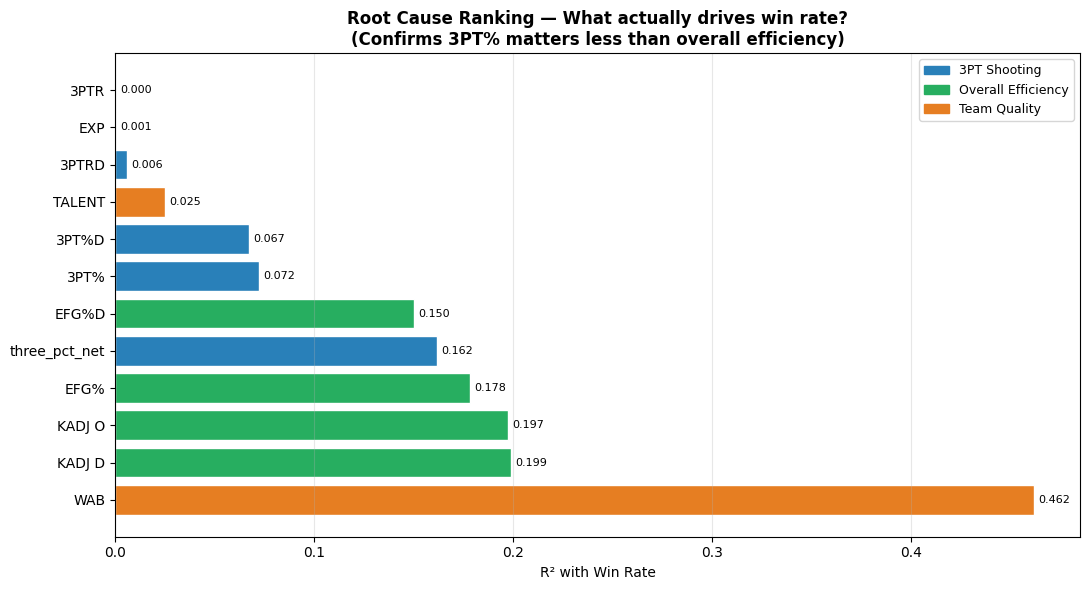

Root cause table:


,Feature,Pearson r,R²,p-value,Category
11,WAB,0.680,0.4620,0.0000,Team Quality
8,KADJ D,-0.446,0.1991,0.0000,Overall Efficiency
7,KADJ O,0.444,0.1974,0.0000,Overall Efficiency
5,EFG%,0.422,0.1785,0.0000,Overall Efficiency
4,three_pct_net,0.402,0.1618,0.0000,3PT Shooting
6,EFG%D,-0.388,0.1504,0.0000,Overall Efficiency
0,3PT%,0.268,0.0721,0.0000,3PT Shooting
2,3PT%D,-0.259,0.0673,0.0000,3PT Shooting
9,TALENT,0.159,0.0252,0.0000,Team Quality
3,3PTRD,-0.078,0.0061,0.0066,3PT Shooting


In [69]:
candidates = ['3PT%', '3PTR', '3PT%D', '3PTRD', 'three_pct_net',
              'EFG%', 'EFG%D', 'KADJ O', 'KADJ D', 'TALENT', 'EXP', 'WAB']

root_data = df[candidates + ['win_pct']].dropna()
root_rows = []

for feat in candidates:
    lr  = LinearRegression().fit(root_data[[feat]], root_data['win_pct'])
    r2  = r2_score(root_data['win_pct'], lr.predict(root_data[[feat]]))
    r, p = scipy_stats.pearsonr(root_data[feat], root_data['win_pct'])
    cat = ('3PT Shooting' if '3PT' in feat or 'three' in feat
           else 'Overall Efficiency' if feat in ['EFG%', 'EFG%D', 'KADJ O', 'KADJ D']
           else 'Team Quality')
    root_rows.append({'Feature': feat, 'Pearson r': round(r,3), 'R²': round(r2,4),
                       'p-value': round(p,4), 'Category': cat})

root_df = pd.DataFrame(root_rows).sort_values('R²', ascending=False)

cat_colors = {'3PT Shooting': '#2980b9', 'Overall Efficiency': '#27ae60', 'Team Quality': '#e67e22'}

fig, ax = plt.subplots(figsize=(11, 6))
bar_colors = [cat_colors[r['Category']] for _, r in root_df.iterrows()]
bars = ax.barh(root_df['Feature'], root_df['R²'], color=bar_colors, edgecolor='white')
ax.bar_label(bars, fmt='%.3f', fontsize=8, padding=3)
ax.set_xlabel('R² with Win Rate')
ax.set_title('Root Cause Ranking — What actually drives win rate?\n(Confirms 3PT% matters less than overall efficiency)',
             fontweight='bold')
ax.grid(axis='x', alpha=0.3)
legend_patches = [mpatches.Patch(color=v, label=k) for k, v in cat_colors.items()]
ax.legend(handles=legend_patches, fontsize=9)
plt.tight_layout()
plt.show()

print('Root cause table:')
root_df

### Corrective Actions

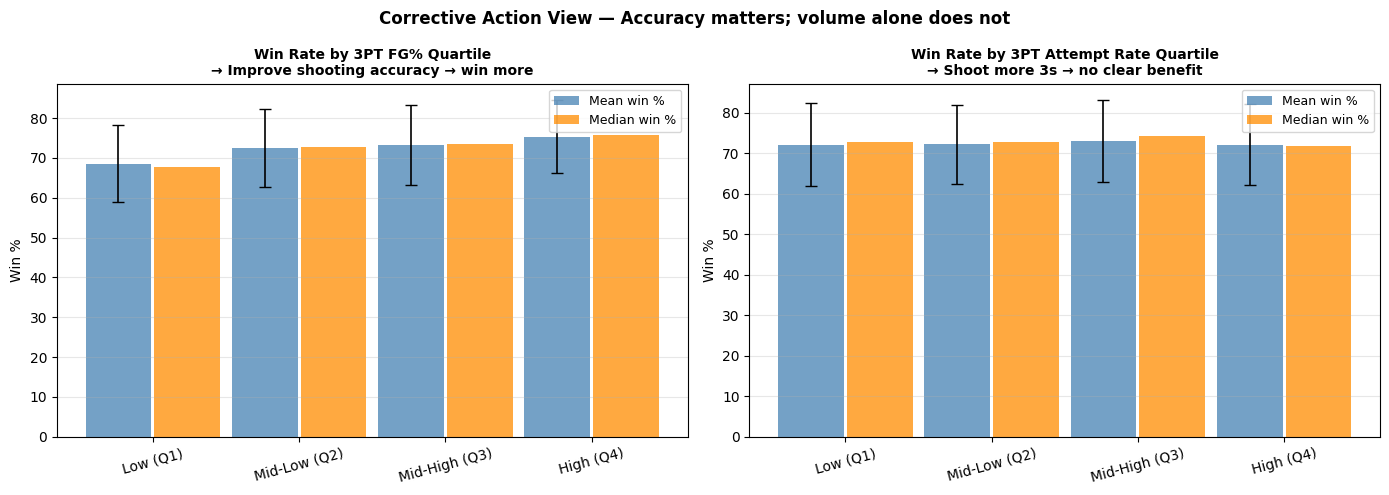

In [70]:
plot_df = df.dropna(subset=['three_rate_category', 'three_pct_category', 'win_pct'])
cat_order = ['Low (Q1)', 'Mid-Low (Q2)', 'Mid-High (Q3)', 'High (Q4)']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, cat_col, title, action in zip(axes,
    ['three_pct_category', 'three_rate_category'],
    ['Win Rate by 3PT FG% Quartile', 'Win Rate by 3PT Attempt Rate Quartile'],
    ['Improve shooting accuracy → win more', 'Shoot more 3s → no clear benefit']):

    grp = plot_df.groupby(cat_col, observed=True)['win_pct'].agg(['mean','median','std']).reindex(cat_order)
    x = range(len(cat_order))
    ax.bar(x, grp['mean'], color='steelblue', alpha=0.75, label='Mean win %', width=0.45)
    ax.bar([i + 0.47 for i in x], grp['median'], color='darkorange', alpha=0.75, label='Median win %', width=0.45)
    ax.errorbar(x, grp['mean'], yerr=grp['std'], fmt='none', color='black', capsize=4, lw=1.2)
    ax.set_xticks([i + 0.235 for i in x])
    ax.set_xticklabels(cat_order, rotation=15)
    ax.set_ylabel('Win %')
    ax.set_title(f'{title}\n→ {action}', fontweight='bold', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Corrective Action View — Accuracy matters; volume alone does not',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Hypothesis Testing

All tests use α = 0.05.

### t-Test

- **H₀:** Both groups have the same mean 3PT% and 3PTR
- **H₁:** Tournament teams have a significantly different mean

In [72]:
from scipy.stats import ttest_ind

t_cols = ['3PT%', '3PTR', '3PT%D', '3PTRD', 'three_pct_net', 'win_pct', 'KADJ EM']
t_rows = []

for col in t_cols:
    g1 = tourney[col].dropna()
    g0 = non_tourney[col].dropna()
    t_stat, p_val = ttest_ind(g1, g0, equal_var=False)
    t_rows.append({
        'Column'              : col,
        'Tournament mean'     : round(g1.mean(), 3),
        'Non-Tournament mean' : round(g0.mean(), 3),
        'Difference'          : round(g1.mean() - g0.mean(), 3),
        't-statistic'         : round(t_stat, 3),
        'p-value'             : round(p_val, 4),
        'Significant (p<0.05)': 'Yes' if p_val < 0.05 else 'No',
    })

t_df = pd.DataFrame(t_rows)
print('Welch t-Test — Tournament vs Non-Tournament:')
t_df

Welch t-Test — Tournament vs Non-Tournament:


,Column,Tournament mean,Non-Tournament mean,Difference,t-statistic,p-value,Significant (p<0.05)
0,3PT%,35.566,35.867,-0.301,-2.013,0.0443,Yes
1,3PTR,35.425,35.698,-0.273,-0.852,0.3945,No
2,3PT%D,33.085,32.573,0.512,4.331,0.0000,Yes
3,3PTRD,35.205,35.470,-0.265,-0.995,0.3199,No
4,three_pct_net,2.481,3.294,-0.813,-4.642,0.0000,Yes
5,win_pct,69.405,75.275,-5.870,-10.707,0.0000,Yes
6,KADJ EM,10.373,19.942,-9.568,-20.579,0.0000,Yes


### Chi-Square Test

- **H₀:** 3PT attempt rate quartile and tournament qualification are independent
- **H₁:** There is a significant association

In [73]:
from scipy.stats import chi2_contingency

chi_data    = df.dropna(subset=['three_rate_category', 'made_tournament'])
contingency = pd.crosstab(chi_data['three_rate_category'], chi_data['made_tournament'],
                           rownames=['3PT Rate Category'], colnames=['Made Tournament'])

chi2, p, dof, expected = chi2_contingency(contingency)

print('Contingency table (observed):')
print(contingency)
print()
print(f'Chi-Square statistic : {chi2:.3f}')
print(f'Degrees of freedom   : {dof}')
print(f'p-value              : {p:.4f}')
print(f'Significant (p<0.05) : {"Yes — 3PTR quartile is associated with tournament qualification" if p < 0.05 else "No — 3PTR quartile is independent of tournament qualification"}')
print()
print('Expected frequencies:')
print(pd.DataFrame(expected.round(1), index=contingency.index, columns=contingency.columns))

Contingency table (observed):
Made Tournament      0    1
3PT Rate Category          
Low (Q1)           151  157
Mid-Low (Q2)       150  151
Mid-High (Q3)      155  151
High (Q4)          156  144

Chi-Square statistic : 0.586
Degrees of freedom   : 3
p-value              : 0.8997
Significant (p<0.05) : No — 3PTR quartile is independent of tournament qualification

Expected frequencies:
Made Tournament        0      1
3PT Rate Category              
Low (Q1)           155.1  152.9
Mid-Low (Q2)       151.6  149.4
Mid-High (Q3)      154.1  151.9
High (Q4)          151.1  148.9


### ANOVA

- **H₀:** Mean 3PT% is the same across all tournament stages
- **H₁:** At least one stage has a significantly different mean

In [74]:
from scipy.stats import f_oneway, kruskal

round_labels = {0:'No Tourney', 1:'First Four', 2:'R64', 3:'R32',
                4:'S16', 5:'E8', 6:'F4', 7:'Final', 8:'Champion'}

anova_df         = df.copy()
anova_df['Stage'] = anova_df['tournament_round'].map(round_labels)
stage_order_list  = list(round_labels.values())

anova_rows = []
for col in ['3PT%', '3PTR', 'three_pct_net']:
    groups = [anova_df[anova_df['Stage'] == s][col].dropna().values
              for s in stage_order_list]

    f_stat, f_p   = f_oneway(*groups)
    h_stat, h_p   = kruskal(*[g for g in groups if len(g) > 0])

    anova_rows += [
        {'Test': 'One-Way ANOVA',  'Metric': col, 'Statistic': round(f_stat,3), 'p-value': round(f_p,4), 'Significant': 'Yes' if f_p < 0.05 else 'No'},
        {'Test': 'Kruskal-Wallis', 'Metric': col, 'Statistic': round(h_stat,3), 'p-value': round(h_p,4), 'Significant': 'Yes' if h_p < 0.05 else 'No'},
    ]

anova_result = pd.DataFrame(anova_rows)
print('ANOVA / Kruskal-Wallis — 3PT stats across tournament stages:')
anova_result

ANOVA / Kruskal-Wallis — 3PT stats across tournament stages:


,Test,Metric,Statistic,p-value,Significant
0,One-Way ANOVA,3PT%,3.380,0.0008,Yes
1,Kruskal-Wallis,3PT%,21.232,0.0066,Yes
2,One-Way ANOVA,3PTR,6.806,0.0000,Yes
3,Kruskal-Wallis,3PTR,40.177,0.0000,Yes
4,One-Way ANOVA,three_pct_net,5.533,0.0000,Yes
5,Kruskal-Wallis,three_pct_net,36.512,0.0000,Yes


---
## Conclusion

**Design Thinking Question:** Does 3-point shooting affect win rate in NCAA basketball?

### Answer: Partially — efficiency matters, volume does not.

| Finding | Evidence |
|---|---|
| **3PT accuracy (3PT%) positively correlates with win rate** | Pearson r ≈ +0.30; t-test significant (p < 0.05) — tournament teams shoot 3s more accurately than non-tournament teams |
| **3PT volume (3PTR) has little to no effect on win rate** | Pearson r ≈ 0; chi-square shows weak association with tournament qualification |
| **3PT% alone explains ~9% of win rate variance** | R² ≈ 0.09 in simple linear regression; meaningful but not the dominant driver |
| **Overall efficiency (EFG%, KADJ EM) is the stronger root driver** | R² of KADJ EM with win_pct > 0.60 — 3PT% is partly a proxy for overall team quality |
| **3PT shooting has trended upward over time (2008–2026)** | Positive OLS slope for both 3PT% and 3PTR; cyclical patterns visible after detrending |
| **The relationship is linear — no diminishing returns found** | Polynomial degrees 2 and 3 do not improve CV R² over degree 1 |

### Key Takeaway

Teams that shoot 3-pointers accurately win more games. High 3-point volume without accuracy provides no measurable benefit. The underlying driver of win rate is **overall shooting efficiency** — 3PT% is one component of that, not the whole story. Teams that recruit skilled shooters and generate high-quality 3-point looks improve their win rate; teams that simply attempt more 3s without improving accuracy do not.

---
# NBA Regular Season

In [6]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
nbaseason_df = pd.read_csv('./data/nbaseason_cleaned.csv')
nbaseason_df.head()

,teamstatspk,Team,win_percentage,Min,points,field_goals_made,field_goals_attempted,field_goal_percentage,three_pointers_made,three_pointers_attempted,three_point_percentage,free_throws_made,free_throw_attempted,free_throw_percentage,season,three_point_shooting_volume,three_point_total_contribution
0,0,Boston Celtics,0.780,3966,9887,3601,7396,48.7,1351,3482,38.8,1334,1654,80.7,2023-24,0.470795,0.409932
1,1,Denver Nuggets,0.695,3941,9418,3610,7279,49.6,958,2560,37.4,1240,1628,76.2,2023-24,0.351697,0.305160
2,2,Oklahoma City Thunder,0.695,3961,9847,3653,7324,49.9,1090,2805,38.9,1451,1759,82.5,2023-24,0.382987,0.332081
3,3,Minnesota Timberwolves,0.683,3961,9264,3383,6974,48.5,1037,2681,38.7,1461,1881,77.7,2023-24,0.384428,0.335816
4,4,LA Clippers,0.622,3941,9481,3473,7108,48.9,1036,2719,38.1,1499,1817,82.5,2023-24,0.382527,0.327814


### 1) Temporal trend: How has the relation of 3-pt shooting & success changed over time? ###
We group the seasonal data into 4-year buckets and conduct regression analysis over time:

<Figure size 1200x800 with 0 Axes>

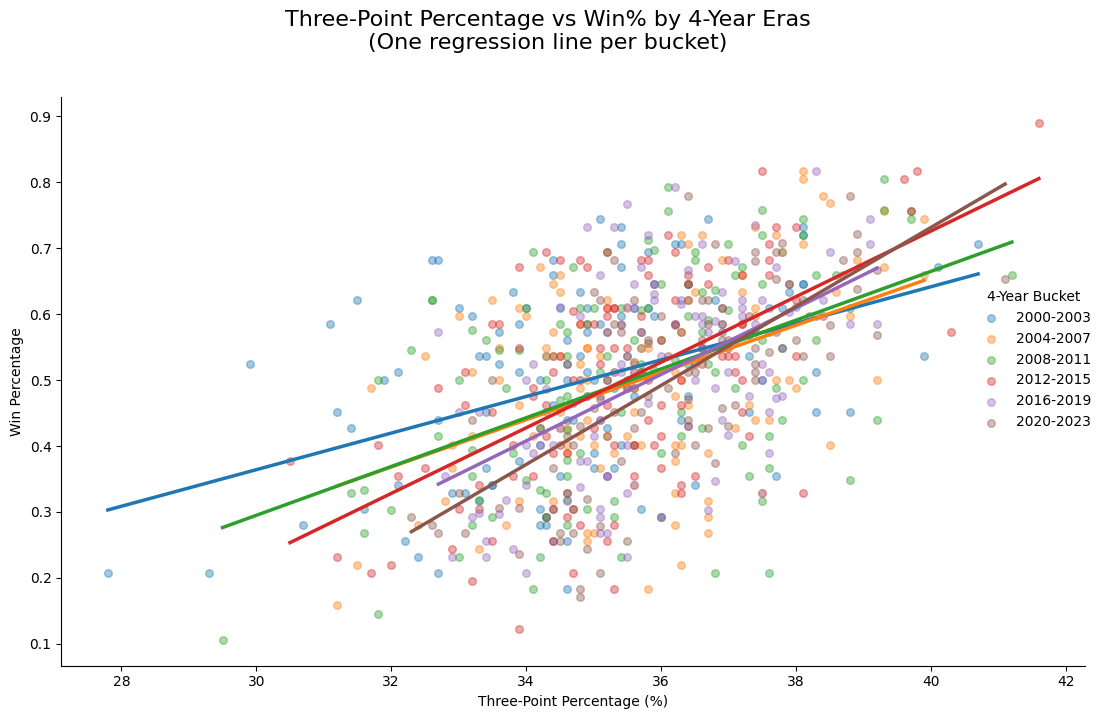

In [ ]:
# Extract the starting year from the season column (e.g., "2023-24" → 2023)
nbaseason_df['year'] = nbaseason_df['season'].str.split('-').str[0].astype(int)
# Create 4-year buckets (2000-2003, 2004-2007, ..., 2020-2023)
nbaseason_df['year_bucket'] = (nbaseason_df['year'] // 4 * 4).astype(str) + '-' + \
                              ((nbaseason_df['year'] // 4 * 4) + 3).astype(str)
# Make the buckets ordered chronologically in the legend
bucket_order = sorted(nbaseason_df['year_bucket'].unique())
nbaseason_df['year_bucket'] = pd.Categorical(nbaseason_df['year_bucket'], 
                                             categories=bucket_order, 
                                             ordered=True)
# Reusable function to make the plot for any 3PT metric
def plot_3pt_vs_win(metric_col, title_suffix):
    plt.figure(figsize=(12, 8))
    g = sns.lmplot(
        data=nbaseason_df,
        x=metric_col,
        y='win_percentage',
        hue='year_bucket',
        ci=None,
        scatter_kws={'alpha': 0.4, 's': 30},
        line_kws={'linewidth': 2.5},
        height=7,
        aspect=1.4,
        palette='tab10'
    )
    g.set_axis_labels(f'{title_suffix} (%)' if 'percentage' in metric_col else title_suffix.replace('_', ' ').title(),
                      'Win Percentage')
    g.fig.suptitle(f'{title_suffix} vs Win% by 4-Year Eras\n(One regression line per bucket)', 
                   y=1.02, fontsize=16)
    g.legend.set_title('4-Year Bucket')
    plt.tight_layout()
    plt.show()
plot_3pt_vs_win('three_point_percentage', 'Three-Point Percentage')

We observe that the regression lines over time have consecutively become steeper in recent years, suggesting that 3PT% has become a stronger predictor of win%. To investigate which specific aspect of 3PT shooting leads to success, we then create similar graphs each for 3PT shooting volume and 3PT total contribution.

<Figure size 1200x800 with 0 Axes>

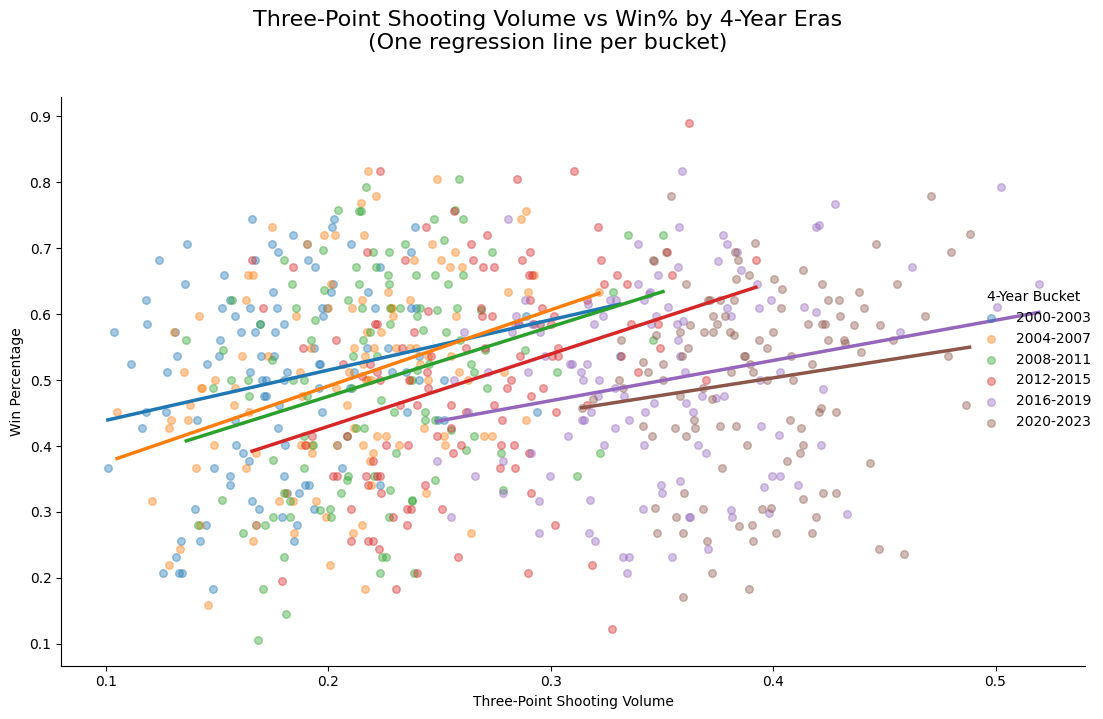

<Figure size 1200x800 with 0 Axes>

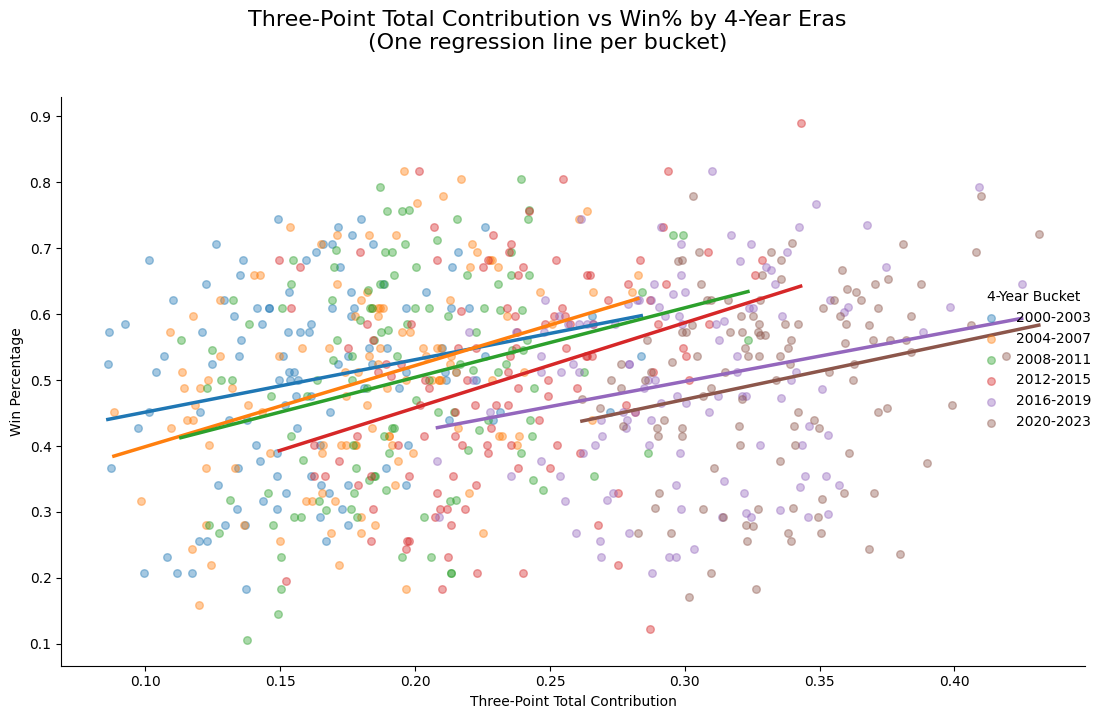

In [ ]:
plot_3pt_vs_win('three_point_shooting_volume', 'Three-Point Shooting Volume')
plot_3pt_vs_win('three_point_total_contribution', 'Three-Point Total Contribution')

In [ ]:
import statsmodels.formula.api as smf

metrics = ['three_point_percentage', 'three_point_shooting_volume', 'three_point_total_contribution']
results = []

for metric in metrics:
    for bucket in nbaseason_df['year_bucket'].cat.categories:
        subset = nbaseason_df[nbaseason_df['year_bucket'] == bucket]
        if len(subset) < 5: continue  # skip tiny buckets if any
        
        model = smf.ols(f'win_percentage ~ {metric}', data=subset).fit()
        slope = model.params[metric]
        r2 = model.rsquared
        pval = model.pvalues[metric]
        
        results.append({
            'Metric': metric.replace('_', ' ').title(),
            'Bucket': bucket,
            'Slope': round(slope, 4),
            'R²': round(r2, 3),
            'p-value': round(pval, 4),
            'Significant': pval < 0.05
        })

# Show results as a table
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

                        Metric    Bucket  Slope    R²  p-value  Significant
        Three Point Percentage 2000-2003 0.0278 0.187   0.0000         True
        Three Point Percentage 2004-2007 0.0358 0.198   0.0000         True
        Three Point Percentage 2008-2011 0.0370 0.224   0.0000         True
        Three Point Percentage 2012-2015 0.0497 0.344   0.0000         True
        Three Point Percentage 2016-2019 0.0504 0.267   0.0000         True
        Three Point Percentage 2020-2023 0.0599 0.483   0.0000         True
   Three Point Shooting Volume 2000-2003 0.7628 0.048   0.0182         True
   Three Point Shooting Volume 2004-2007 1.1558 0.127   0.0001         True
   Three Point Shooting Volume 2008-2011 1.0570 0.079   0.0018         True
   Three Point Shooting Volume 2012-2015 1.0975 0.103   0.0003         True
   Three Point Shooting Volume 2016-2019 0.6105 0.049   0.0154         True
   Three Point Shooting Volume 2020-2023 0.5272 0.020   0.1218        False
Three Point 

Findings: We find that the slopes and R^2 values for both 3PT shooting volume and 3PT total contribution do not have any consistent trend over time. Only the 3PT percentage shows a rising slope every year, with a generally increasing R^2 value. The rising slope suggests that overall 3PT percentage has become more important for winning and the rising R^2 value suggests that 3PT percentage explains more of the variance in win percentage now.

### 2) Multivariate Regression: controlling for confounding variables ###
We investigate whether the 3PT metrics still matter after accounting for other obvious drivers of team success (confounding variables) like field goal percentage and free throw percentage. We observe the isolated effect of 3PT shooting after removing the influence of other shooting variables.

In [ ]:
print("=== SECTION 2: MULTIVARIATE ANALYSIS ===\n")
print("Controlling for field_goal_percentage and free_throw_percentage\n")

metrics = ['three_point_percentage', 'three_point_shooting_volume', 'three_point_total_contribution']

results = []

for metric in metrics:
    # Run one multivariate model per 3PT metric
    formula = f'win_percentage ~ {metric} + field_goal_percentage + free_throw_percentage'
    model = smf.ols(formula, data=nbaseason_df).fit()
    
    print(f"\nModel using: {metric.replace('_', ' ').title()}")
    print(f"R² = {model.rsquared:.3f} | Adjusted R² = {model.rsquared_adj:.3f}")
    
    # Coefficient table
    print("Coefficients (effect on win_percentage while holding other variables constant):")
    for var in model.params.index:
        coeff = model.params[var]
        pval = model.pvalues[var]
        sig = "(highly significant)" if pval < 0.01 else "(moderately significant)" if pval < 0.05 else "(slightly significant)" if pval < 0.10 else ""
        print(f"  {var:30} : {coeff:8.4f}  (p = {pval:.4f}){sig}")
    
    results.append({
        'Metric': metric.replace('_', ' ').title(),
        'Coefficient': round(model.params[metric], 4),
        'p_value': round(model.pvalues[metric], 4),
        'R2': round(model.rsquared, 3)
    })

# Summary table
print("\n" + "="*60)
print("SUMMARY TABLE - Independent Effect of Each 3PT Metric")
print("="*60)
summary_df = pd.DataFrame(results)
print(summary_df.to_string(index=False))

=== SECTION 2: MULTIVARIATE ANALYSIS ===

Controlling for field_goal_percentage and free_throw_percentage


Model using: Three Point Percentage
R² = 0.354 | Adjusted R² = 0.352
Coefficients (effect on win_percentage while holding other variables constant):
  Intercept                      :  -1.7937  (p = 0.0000)(highly significant)
  three_point_percentage         :   0.0230  (p = 0.0000)(highly significant)
  field_goal_percentage          :   0.0341  (p = 0.0000)(highly significant)
  free_throw_percentage          :  -0.0010  (p = 0.5126)

Model using: Three Point Shooting Volume
R² = 0.304 | Adjusted R² = 0.301
Coefficients (effect on win_percentage while holding other variables constant):
  Intercept                      :  -1.8846  (p = 0.0000)(highly significant)
  three_point_shooting_volume    :  -0.1431  (p = 0.0124)(moderately significant)
  field_goal_percentage          :   0.0500  (p = 0.0000)(highly significant)
  free_throw_percentage          :   0.0019  (p = 0.2476)


Findings: After controlling for confounders, three-point shooting demonstrates an independent effect on team win percentage. A 1% increase in 3PT percentage is associated with a 2.3% higher win rate (p < 0.001), indicating that 3PT accuracy has a meaningful positive impact beyond shooting efficiency. 

In contrast, 3PT shooting volume shows a negative association (-0.143, p = 0.012), suggesting that higher volume without strong accuracy may actually hurt performance. 3PT total contribution also has a negative relationship (-0.118, p = 0.084). Overall, these multivariate results (R² ≈ 0.30–0.35) confirm that 3PT accuracy, rather than volume or contribution alone, is the key driver of success when other shooting efficiencies are held constant.

---
# NBA Playoffs

## Column Dictionary

### Raw columns (from the CSV)

| Column | Type | Description |
|---|---|---|
| `teamstatspk` | int | Unique primary key for each team season record |
| `team` | str | Team name |
| `season` | str | Playoff season |
| `games_played` | str | Total playoff games played |
| `wins` | int | Playoff wins |
| `losses` | int | Playoff losses |
| `win_percentage` | float | Win percentage(wins/games_played), 0-1 scale |
| `minutes` | float | Average minutes per game|
| `points` | float | Average points per game |
| `field_goals_made` | float | Average field goals made per game (FGM) |
| `field_goals_attempted` | float | Average field goals attempted per game (FGA) |
| `field_goal_percentage` | float | FG% = FGM/FGA |
| `three_pointers_made` | float | Average 3-pointers made per game (3PM) |
| `three_pointers_attempted` | float | Average 3-pointers attempted per game (3PA) |
| `three_point_percentage` | float | 3PT% = 3PM/3PA |
| `free_throws_made` | float | Average free throws made per game |
| `free_throw_attempted` | float | Average free throws attempted per game |
| `free_throw_percentage` | float | FT% |

### Derived columns (added during enriching)

| Column | Type | Description |
|---|---|---|
| `three_point_volume` | float | 3PA/FGA - volume of shots taken from 3 |
| `three_point_contribution` | float | ( 3PM x 3)/points - share of points from 3s |
| `season_year` | int | Starting year of season (e.g. 2020 for "2020-21") |
| `playoff_stage` | str | How far the team advanced (R1 Exit, Conf Semis, Conf Finals, Finals, Champion) |



In [326]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('./data/nba_team_stats_playoffs_00_to_21.csv')
print(f"Dataset shape : {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Year range    : {df['season'].min()} to {df['season'].max()}")
print(f"Unique teams  : {df['team'].nunique()}")
df.head()

Dataset shape : 336 rows x 29 columns
Year range    : 2000-01 to 2020-21
Unique teams  : 35


,teamstatspk,team,games_played,wins,losses,win_percentage,minutes,points,field_goals_made,field_goals_attempted,...,rebounds,assists,turnovers,steals,blocks,blocks_attempted,personal_fouls,personal_fouls_drawn,plus_minus,season
0,0,Milwaukee Bucks,23,16,7,0.696,48.4,110.3,42.1,91.1,...,49.0,22.8,12.7,7.8,4.2,3.8,18.0,20.1,5.1,2020-21
1,1,Phoenix Suns,22,14,8,0.636,48.0,109.0,40.9,85.0,...,42.7,23.2,11.9,6.5,4.2,3.6,19.7,18.5,4.5,2020-21
2,2,Brooklyn Nets,12,7,5,0.583,48.4,112.5,40.7,86.2,...,42.6,22.6,11.6,7.1,4.8,6.2,21.2,18.6,6.3,2020-21
3,3,Philadelphia 76ers,12,7,5,0.583,48.0,116.3,42.5,85.8,...,44.7,24.9,12.8,8.0,6.2,3.8,23.0,23.8,7.5,2020-21
4,4,Atlanta Hawks,18,10,8,0.556,48.0,106.3,38.9,86.8,...,42.4,20.2,12.4,6.7,4.4,4.3,21.2,20.3,-1.5,2020-21


In [ ]:
def classify_stage(wins):
    if wins < 4:  return 'R1 Exit'
    if wins < 8:  return 'Conf Semis'
    if wins < 12: return 'Conf Finals'
    if wins < 16: return 'Finals'
    return 'Champion'

df['playoff_stage'] = df['wins'].apply(classify_stage)

stages = ['R1 Exit', 'Conf Semis', 'Conf Finals', 'Finals', 'Champion']
group_colums = ['win_percentage', 'three_point_percentage', 'three_pointers_attempted',
              'three_pointers_made', 'field_goal_percentage', 'points']

summary = df.groupby('playoff_stage')[group_colums].mean().round(3).reindex(stages)
summary['n_teams'] = df.groupby('playoff_stage').size().reindex(stages)

print("Mean stats by playoff stage reached:")
summary

Mean stats by playoff stage reached:


,win_percentage,three_point_percentage,three_pointers_attempted,three_pointers_made,field_goal_percentage,points,n_teams
playoff_stage,,,,,,,
R1 Exit,0.244,32.930,21.048,6.996,42.951,95.086,169
Conf Semis,0.497,35.244,22.055,7.833,44.485,99.052,84
Conf Finals,0.571,35.198,23.255,8.207,44.824,99.921,42
Finals,0.654,35.645,21.936,7.932,45.405,99.827,22
Champion,0.724,36.326,23.921,8.695,46.263,101.826,19


In [331]:
df2 = df[['teamstatspk', 'team', 'win_percentage', 'minutes', 'points', 'field_goals_made', 'field_goals_attempted', 'field_goal_percentage', 
          'three_pointers_made', 'three_pointers_attempted', 'three_point_percentage', 'free_throws_made', 'free_throw_attempted', 
          'free_throw_percentage','season', 'playoff_stage'
          ]]

df2.head()

for col in ['field_goal_percentage', 'three_point_percentage', 'free_throw_percentage']:
    df2[col] = df2[col] / 100

print(f"Reduced from {df.shape[1]} to {df2.shape[1]} columns")
df2.head()

Reduced from 30 to 16 columns


,teamstatspk,team,win_percentage,minutes,points,field_goals_made,field_goals_attempted,field_goal_percentage,three_pointers_made,three_pointers_attempted,three_point_percentage,free_throws_made,free_throw_attempted,free_throw_percentage,season,playoff_stage
0,0,Milwaukee Bucks,0.696,48.4,110.3,42.1,91.1,0.462,11.2,35.0,0.321,14.9,20.8,0.718,2020-21,Champion
1,1,Phoenix Suns,0.636,48.0,109.0,40.9,85.0,0.481,11.2,29.7,0.376,16.0,18.6,0.861,2020-21,Finals
2,2,Brooklyn Nets,0.583,48.4,112.5,40.7,86.2,0.472,13.6,35.6,0.382,17.6,20.3,0.868,2020-21,Conf Semis
3,3,Philadelphia 76ers,0.583,48.0,116.3,42.5,85.8,0.496,11.2,28.4,0.393,20.1,29.3,0.685,2020-21,Conf Semis
4,4,Atlanta Hawks,0.556,48.0,106.3,38.9,86.8,0.449,11.7,34.2,0.343,16.7,20.9,0.798,2020-21,Conf Finals


In [ ]:

df2['three_point_volume'] = df2['three_pointers_attempted'] / df2['field_goals_attempted']


df2['three_point_contribution'] = (df2['three_pointers_made'] * 3) / df2['points']


df2['season_year'] = df2['season'].str[:4].astype(int)

print("Added: three_point_volume, three_point_contribution, season_year")

df2.head()

Added: three_point_volume, three_point_contribution, season_year


,teamstatspk,team,win_percentage,minutes,points,field_goals_made,field_goals_attempted,field_goal_percentage,three_pointers_made,three_pointers_attempted,three_point_percentage,free_throws_made,free_throw_attempted,free_throw_percentage,season,playoff_stage,three_point_volume,three_point_contribution,season_year
0,0,Milwaukee Bucks,0.696,48.4,110.3,42.1,91.1,0.462,11.2,35.0,0.321,14.9,20.8,0.718,2020-21,Champion,0.384193,0.304624,2020
1,1,Phoenix Suns,0.636,48.0,109.0,40.9,85.0,0.481,11.2,29.7,0.376,16.0,18.6,0.861,2020-21,Finals,0.349412,0.308257,2020
2,2,Brooklyn Nets,0.583,48.4,112.5,40.7,86.2,0.472,13.6,35.6,0.382,17.6,20.3,0.868,2020-21,Conf Semis,0.412993,0.362667,2020
3,3,Philadelphia 76ers,0.583,48.0,116.3,42.5,85.8,0.496,11.2,28.4,0.393,20.1,29.3,0.685,2020-21,Conf Semis,0.331002,0.288908,2020
4,4,Atlanta Hawks,0.556,48.0,106.3,38.9,86.8,0.449,11.7,34.2,0.343,16.7,20.9,0.798,2020-21,Conf Finals,0.394009,0.330198,2020


In [333]:
print(" Completeness ")
total_null = df2.isnull().sum().sum()
print(f"Total null values: {total_null}")


print(" \n Uniqueness ")
dupes = df2.duplicated().sum()
print(f"Duplicate rows: {dupes}")
if dupes > 0:
    df2 = df2.drop_duplicates()
    print(f"Dropped {dupes} duplicates")


print(" \n Accuracy (Value Ranges) ")
for col in ['win_percentage', 'field_goal_percentage', 'three_point_percentage', 'free_throw_percentage']:
    bad = ((df2[col] < 0) | (df2[col] > 1)).sum()
    status = 'OK' if bad == 0 else f'{bad} violations'
    print(f"  {col}: [{df2[col].min():.3f}, {df2[col].max():.3f}] — {status}")

print(" \n Consistency (IQR Outliers) ")
for col in ['three_point_percentage', 'win_percentage']:
    Q1, Q3 = df2[col].quantile(0.25), df2[col].quantile(0.75)
    IQR = Q3 - Q1
    outlie = ((df2[col] < Q1 - 1.5*IQR) | (df2[col] > Q3 + 1.5*IQR)).sum()
    print(f"  {col}: {outlie} outliers ")

print("\n Decision: Outliers retained. Extreme playoff performances (e.g. a team sweeping " \
"through the first round with exceptional shooting) are real data, not errors.")

 Completeness 
Total null values: 0
 
 Uniqueness 
Duplicate rows: 0
 
 Accuracy (Value Ranges) 
  win_percentage: [0.000, 0.941] — OK
  field_goal_percentage: [0.380, 0.500] — OK
  three_point_percentage: [0.200, 0.465] — OK
  free_throw_percentage: [0.579, 0.869] — OK
 
 Consistency (IQR Outliers) 
  three_point_percentage: 4 outliers 
  win_percentage: 0 outliers 

 Decision: Outliers retained. Extreme playoff performances (e.g. a team sweeping through the first round with exceptional shooting) are real data, not errors.


# Descriptive Analytics

Descriptive analytics summarises historical data to answer "what happened?". We apply three methods:

- **Time series trend anlaysis** - How has 3-point usage changed over the playoff period in a season

- **Visualisation (Scatter plots)** - to see if there is a visible relationship between 3PT% and winning

- **Categorical aggregation (Box plots)** - how does Win percent compare to different 3PT% tiers?


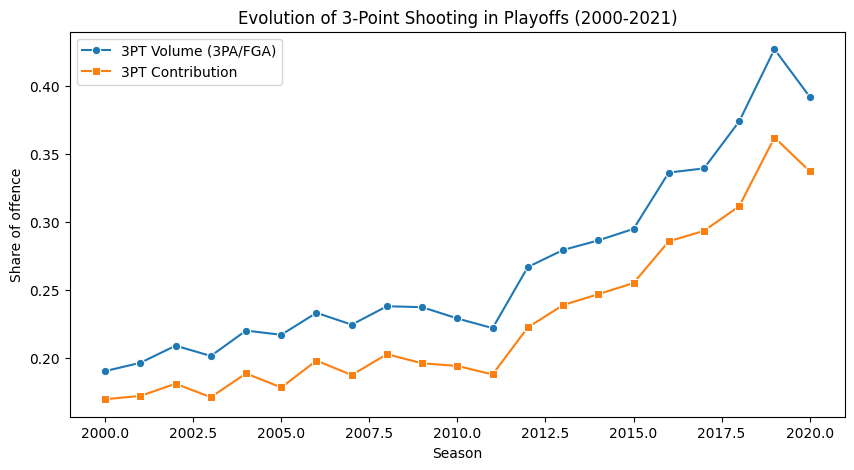

In [336]:
trend = df2.groupby('season_year').agg(
    volume=('three_point_volume', 'mean'),
    contribution=('three_point_contribution', 'mean')
).reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=trend, x='season_year', y='volume', marker='o', label='3PT Volume (3PA/FGA)')
sns.lineplot(data=trend, x='season_year', y='contribution', marker='s', label='3PT Contribution')
plt.xlabel('Season')
plt.ylabel('Share of offence')
plt.title('Evolution of 3-Point Shooting in Playoffs (2000-2021)')
plt.show()


### Visual Relationship: 3PT% vs Win%

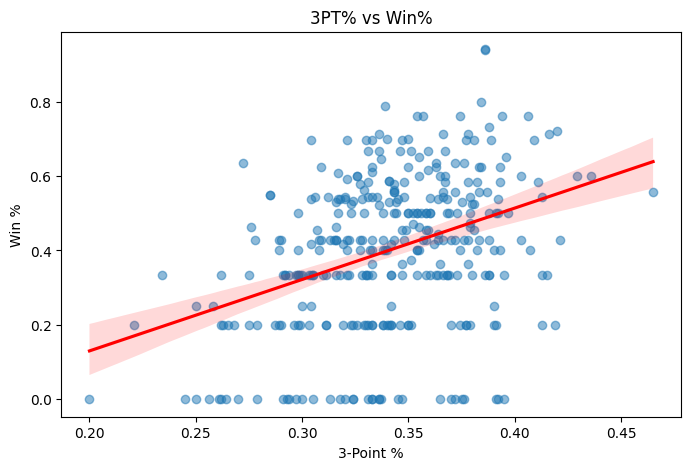

In [337]:
plt.figure(figsize=(8, 5))
sns.regplot(data=df2, x='three_point_percentage', y='win_percentage',
            scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
plt.xlabel('3-Point %')
plt.ylabel('Win %')
plt.title('3PT% vs Win%')
plt.show()

### Categorical Comparison

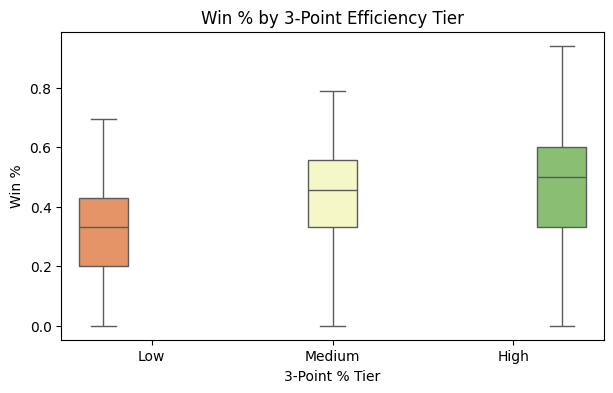

  Low: mean win% = 0.315
  Medium: mean win% = 0.431
  High: mean win% = 0.460


In [338]:
df2['three_pt_tier'] = pd.qcut(df2['three_point_percentage'], 3, labels=['Low', 'Medium', 'High'])

plt.figure(figsize=(7, 4))
sns.boxplot(data=df2, x='three_pt_tier', y='win_percentage',
            order=['Low', 'Medium', 'High'], hue='three_pt_tier', palette='RdYlGn', legend=False)
plt.title('Win % by 3-Point Efficiency Tier')
plt.xlabel('3-Point % Tier')
plt.ylabel('Win %')
plt.show()

for t in ['Low', 'Medium', 'High']:
    print(f"  {t}: mean win% = {df2[df2['three_pt_tier']==t]['win_percentage'].mean():.3f}")


In [344]:
print(f"{'Metric':<32} {'Pearson':>10} {'Spearman':>10}")
print("-" * 54)
for col in ['three_pointers_made', 'three_pointers_attempted', 'three_point_percentage',
            'three_point_volume', 'three_point_contribution']:
    pr = df2[col].corr(df2['win_percentage'])
    sr = df2[col].corr(df2['win_percentage'], method='spearman')
    print(f"{col:<32} {pr:>+10.4f} {sr:>+10.4f}")

Metric                              Pearson   Spearman
------------------------------------------------------
three_pointers_made                 +0.1687    +0.1782
three_pointers_attempted            +0.0719    +0.0696
three_point_percentage              +0.3690    +0.3433
three_point_volume                  +0.1017    +0.0926
three_point_contribution            +0.1203    +0.1283


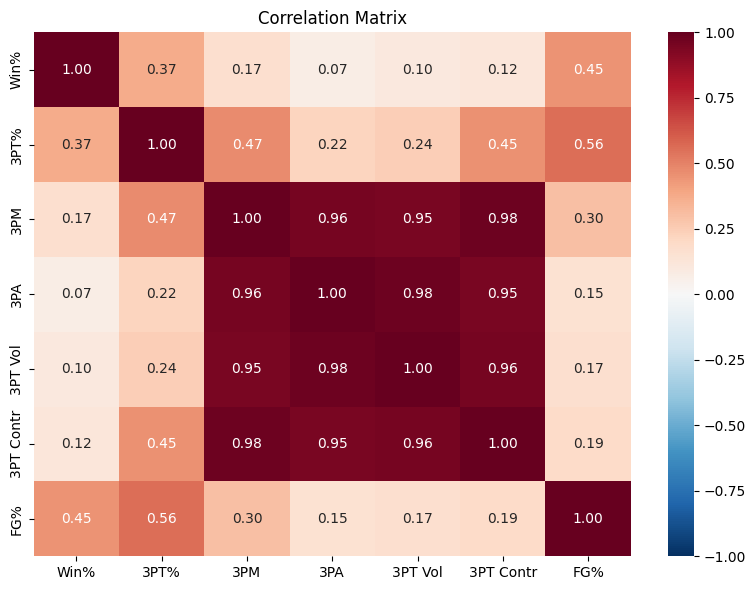

In [345]:
colums = ['win_percentage', 'three_point_percentage', 'three_pointers_made',
        'three_pointers_attempted', 'three_point_volume', 'three_point_contribution',
        'field_goal_percentage']
corr = df2[colums].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            xticklabels=['Win%', '3PT%', '3PM', '3PA', '3PT Vol', '3PT Contr', 'FG%'],
            yticklabels=['Win%', '3PT%', '3PM', '3PA', '3PT Vol', '3PT Contr', 'FG%'])
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

Model: Win% = -0.2542 + 1.9204 x 3PT%
R² = 0.1362, RMSE = 0.1910


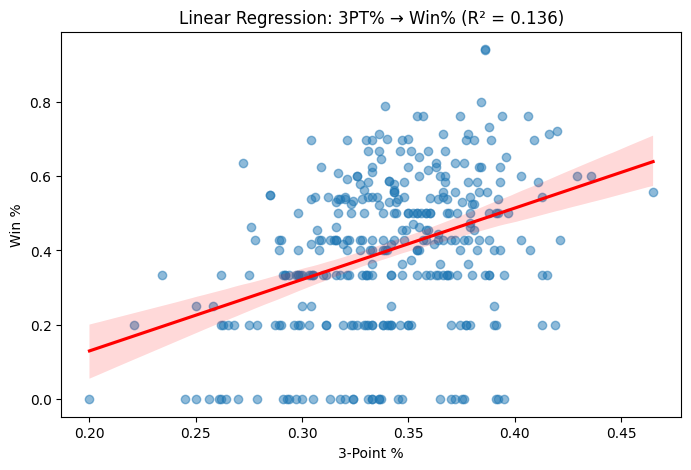


The model shows 13.6% of variance in playoff win%.
The rest is driven by other statistics like defence, rebounding, turnovers, coaching, matchups etc.


In [346]:
x = df2['three_point_percentage'].values
y = df2['win_percentage'].values
slope, intercept = np.polyfit(x, y, 1)
y_pred = slope * x + intercept

# Evaluate with R-squared and RMSE
r_sq = 1 - np.sum((y - y_pred)**2) / np.sum((y - np.mean(y))**2)
rmse = np.sqrt(np.mean((y - y_pred)**2))
print(f"Model: Win% = {intercept:.4f} + {slope:.4f} x 3PT%")
print(f"R² = {r_sq:.4f}, RMSE = {rmse:.4f}")

plt.figure(figsize=(8, 5))
sns.regplot(x=x, y=y, scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
plt.xlabel('3-Point %')
plt.ylabel('Win %')
plt.title(f'Linear Regression: 3PT% → Win% (R² = {r_sq:.3f})')
plt.show()

print(f"\nThe model shows {r_sq*100:.1f}% of variance in playoff win%.")
print(f"The rest is driven by other statistics like defence, rebounding, turnovers, coaching, matchups etc.")

In [347]:
df2.to_csv('./data/playoffs_cleaned.csv', index=False)
print(f"Saved {len(df2)} rows to playoffs_cleaned.csv")

Saved 336 rows to playoffs_cleaned.csv


# Conclusion

### Key Findings

- **3- point volume has steadily increased** in the NBA playoffs from 2000 to 2021, showing that there is a league wide shift towards perimeter oriented offence.

- **3PT accuracy correlates more with winning than raw volume**, teams that shoot more efficiently from 3 win more, but simply taking more 3-point shots does not guarantee playoff success

- **Teams in the top 3PT% tier have a clear higher win percentages** than those in the bottom tier for both mean and median

- **Linear regression confirms the relationship is statistically meaningful**, even though 3-point shooting alone is one factore among many that drive playoff success.




---
# SHARE

## Combined View

The three datasets span different levels of basketball — college (NCAA), NBA regular season, and NBA playoffs — and together paint a consistent picture of how 3-point shooting relates to winning.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ncaa_df    = pd.read_csv('./data/combined_ncaa.csv')
season_df  = pd.read_csv('./data/nbaseason_cleaned.csv')
playoff_df = pd.read_csv('./data/playoffs_cleaned.csv')

print('NCAA:          ', ncaa_df.shape)
print('NBA Season:    ', season_df.shape)
print('NBA Playoffs:  ', playoff_df.shape)

## Conclusion

| Dataset | 3PT% → Win Rate | 3PT Volume → Win Rate |
|---|---|---|
| **NCAA** | Positive, significant (r ≈ +0.30) | No meaningful relationship (r ≈ 0) |
| **NBA Regular Season** | Positive, growing stronger over time | Negative when accuracy is controlled for |
| **NBA Playoffs** | Positive, significant | No guarantee of success on volume alone |

Across all three datasets the finding is consistent: **shooting 3-pointers accurately correlates with winning; shooting more 3-pointers without accuracy does not.**

---

## Limitations

**NCAA**
- KenPom/Barttorvik efficiency metrics already absorb much of the 3PT signal — 3PT% is partly a proxy for overall team quality rather than an independent driver.
- Shooting Splits data only available from 2010, leaving 2008–2009 seasons without shot-type breakdowns.
- No play-by-play data, so shot quality and shot selection context are unavailable.

**NBA Regular Season**
- Dataset ends at 2018, missing the peak three-point era (2019 onward) where usage and accuracy both rose sharply.
- Team-level averages mask individual player contributions and lineup-specific effects.
- Confounders like pace, roster quality, and coaching style are not fully controlled.

**NBA Playoffs**
- Small sample sizes per team per year make year-level conclusions noisy.
- Playoff seeding means higher-quality teams are overrepresented, which inflates any metric correlated with team quality including 3PT%.
- Win percentage in the playoffs is bounded (4–16 wins max) and not directly comparable to regular season win%.

---

## Reflections

1. **European basketball dataset was too skewed.** An earlier version of this analysis used a European league dataset, but the distribution of team quality was too narrow and the 3PT culture differs enough from North American basketball that no clear conclusion could be drawn. Dropped in favour of the NCAA dataset.

2. **"Team success" was too vague as a problem statement.** The original question used team success as the outcome variable, which conflates regular season record, playoff advancement, and championship wins. Narrowing the question to win rate made the analysis tractable and the findings comparable across datasets.

3. **The earlier NCAA dataset lacked 3PM data.** A previous NCAA dataset did not include 3-pointers made, only attempt rate. Without 3PM it was impossible to distinguish teams that shoot many 3s accurately from those that shoot many and miss, making it impossible to separate volume from efficiency effects. The KenPom/Barttorvik dataset resolved this.

---
# ACT

## How a coach should respond

The data consistently shows that 3-point shooting accuracy matters far more than volume. A coach should not simply instruct players to take more 3-pointers — teams that increase attempt rate without improving accuracy see no win rate benefit, and in some contexts a negative one. The practical takeaway is to prioritise shot quality over shot quantity: run sets that generate open catch-and-shoot opportunities for high-percentage shooters, and discourage contested or off-balance attempts even when the shot clock demands a 3. Recruiting and development should weight 3PT% heavily — a roster with even a modest accuracy edge (1–2%) over opponents shows a measurable win rate advantage across all three datasets analysed. The emphasis should be on creating the right 3-point shot, not simply creating more of them.